<a href="https://colab.research.google.com/github/rachit-890/AICodeReviewBot/blob/main/tomato_disease_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 0: Session recovery — run this FIRST every time you reconnect to Colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True, timeout_ms=120000)

import os, json, zipfile
import pandas as pd
import numpy as np

DRIVE_ROOT = '/content/drive/MyDrive/PlantDiseaseProject'
LOCAL_ROOT = '/content/data'

# Paths needed by run_experiment() and the dataset audit re-use
pv_color_path = os.path.join(LOCAL_ROOT, 'PlantVillage', 'PlantVillage-Dataset-master', 'raw', 'color')
pc_test_path = os.path.join(LOCAL_ROOT, 'PlantCity', 'test')

# Re-extract datasets to local disk (fast, ~1-2 min, since local disk is wiped each session)
os.makedirs(os.path.join(LOCAL_ROOT, 'PlantVillage'), exist_ok=True)
os.makedirs(os.path.join(LOCAL_ROOT, 'PlantCity'), exist_ok=True)

pv_extract_marker = os.path.join(LOCAL_ROOT, 'PlantVillage', 'PlantVillage-Dataset-master')
if not os.path.isdir(pv_extract_marker):
    print("Extracting PlantVillage...")
    with zipfile.ZipFile(os.path.join(DRIVE_ROOT, 'data_raw', 'PlantVillage-Dataset-master.zip'), 'r') as z:
        z.extractall(os.path.join(LOCAL_ROOT, 'PlantVillage'))
else:
    print("PlantVillage already extracted this session.")

pc_extract_marker = os.path.join(LOCAL_ROOT, 'PlantCity', 'test')
if not os.path.isdir(pc_extract_marker):
    print("Extracting PlantCity...")
    with zipfile.ZipFile(os.path.join(DRIVE_ROOT, 'data_raw', 'PlantCity-Dataset.zip'), 'r') as z:
        z.extractall(os.path.join(LOCAL_ROOT, 'PlantCity'))
else:
    print("PlantCity already extracted this session.")

# Reload the class mapping
with open(os.path.join(DRIVE_ROOT, 'configs', 'class_mapping.json')) as f:
    class_mapping = json.load(f)

# Reload the saved train/val/test splits (these paths point into LOCAL_ROOT, which we just re-extracted identically)
splits_dir = os.path.join(DRIVE_ROOT, 'data', 'splits')
train_df = pd.read_csv(os.path.join(splits_dir, 'train.csv'))
val_df   = pd.read_csv(os.path.join(splits_dir, 'val.csv'))
test_df  = pd.read_csv(os.path.join(splits_dir, 'test.csv'))

with open(os.path.join(splits_dir, 'split_config.json')) as f:
    split_config = json.load(f)
RANDOM_SEED = split_config["random_seed"]

# Sanity check: do the file paths in the split CSVs actually exist after re-extraction?
missing = train_df[~train_df["path"].apply(os.path.exists)]
if len(missing) > 0:
    print(f"WARNING: {len(missing)} paths from train.csv not found after re-extraction!")
    print(missing.head())
else:
    print("All train.csv paths verified present.")

print(f"\nSession restored: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

Mounted at /content/drive
Extracting PlantVillage...
Extracting PlantCity...
All train.csv paths verified present.

Session restored: train=12703, val=2723, test=2720


In [ ]:
# Cell 1: Connect Colab to your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# This is where EVERYTHING for this project will live permanently.
# Change this if you named your Drive folder something else.
PROJECT_ROOT = '/content/drive/MyDrive/PlantDiseaseProject'
print("Project root:", PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/PlantDiseaseProject


In [ ]:
# Cell 2: Set up two roots
# DRIVE_ROOT = permanent storage (small files: zips, reports, results, configs)
# LOCAL_ROOT = temporary per-session storage (large files: unzipped images)
import os

DRIVE_ROOT = '/content/drive/MyDrive/PlantDiseaseProject'
LOCAL_ROOT = '/content/data'   # lives on Colab's local disk, NOT Drive

drive_folders = [
    'data_raw',            # your zips already live here
    'data/splits',          # small CSVs listing which files go in train/val/test
    'reports',
    'results/experiments',
    'results/figures',
    'results/tables',
    'results/figures/gradcam',
    'results/figures/confusion_matrices',
]
for f in drive_folders:
    os.makedirs(os.path.join(DRIVE_ROOT, f), exist_ok=True)

local_folders = ['PlantVillage', 'PlantCity']
for f in local_folders:
    os.makedirs(os.path.join(LOCAL_ROOT, f), exist_ok=True)

print("Drive folders ready under:", DRIVE_ROOT)
print("Local folders ready under:", LOCAL_ROOT)

Drive folders ready under: /content/drive/MyDrive/PlantDiseaseProject
Local folders ready under: /content/data


In [ ]:
# Cell 3: Unzip from Drive into local Colab disk (fast, plenty of space)
import zipfile

plantvillage_zip = os.path.join(DRIVE_ROOT, 'data_raw', 'PlantVillage-Dataset-master.zip')
plantcity_zip     = os.path.join(DRIVE_ROOT, 'data_raw', 'PlantCity-Dataset.zip')

print("Extracting PlantVillage... (this may take a minute or two)")
with zipfile.ZipFile(plantvillage_zip, 'r') as z:
    z.extractall(os.path.join(LOCAL_ROOT, 'PlantVillage'))

print("Extracting PlantCity...")
with zipfile.ZipFile(plantcity_zip, 'r') as z:
    z.extractall(os.path.join(LOCAL_ROOT, 'PlantCity'))

print("Done.")

Extracting PlantVillage... (this may take a minute or two)
Extracting PlantCity...
Done.


In [ ]:
# Cell 4: sanity check the extracted structure
for root_name in ['PlantVillage', 'PlantCity']:
    path = os.path.join(LOCAL_ROOT, root_name)
    print(f"\n--- {root_name} ---")
    print("Top-level contents:", os.listdir(path)[:10])


--- PlantVillage ---
Top-level contents: ['PlantVillage-Dataset-master']

--- PlantCity ---
Top-level contents: ['test']


In [ ]:
# Cell 5: look 2-3 levels deep to find where the actual class folders are
def show_tree(path, prefix="", max_depth=3, depth=0):
    if depth >= max_depth:
        return
    try:
        entries = sorted(os.listdir(path))
    except NotADirectoryError:
        return
    for entry in entries[:15]:  # cap at 15 per level so output stays readable
        full = os.path.join(path, entry)
        print(prefix + entry + ("/" if os.path.isdir(full) else ""))
        if os.path.isdir(full):
            show_tree(full, prefix + "    ", max_depth, depth + 1)

print("=== PlantVillage ===")
show_tree(os.path.join(LOCAL_ROOT, 'PlantVillage'))

print("\n=== PlantCity ===")
show_tree(os.path.join(LOCAL_ROOT, 'PlantCity'))

=== PlantVillage ===
PlantVillage-Dataset-master/
    .gitignore
    CITATION.cff
    README.md
    README_HF.md
    data_distribution_for_SVM/
        test/
        test_mapping.txt
        train/
        train_mapping.txt
    generate_data_for_SVM.py
    generate_lmdb.sh
    generate_mapstring.py
    generated_for_paper/
        generate.py
        img_0_color.eps
        img_0_grayscale.eps
        img_0_segmented.eps
        img_10_color.eps
        img_10_grayscale.eps
        img_10_segmented.eps
        img_11_color.eps
        img_11_grayscale.eps
        img_11_segmented.eps
        img_12_color.eps
        img_12_grayscale.eps
        img_12_segmented.eps
        img_13_color.eps
        img_13_grayscale.eps
    leaf-map.json
    leaf_grouping/
        Google Leaf Counts.zip
        aggregate_map.py
        create_map.py
        filtered_leafmaps/
        leaf-map.json
        leaf_maps/
    logs/
        slurm-476480.out
        slurm-476481.out
        slurm-476482.out
    

In [ ]:
# Cell 6: list exact Tomato class folder names inside raw/color
color_path = os.path.join(LOCAL_ROOT, 'PlantVillage', 'PlantVillage-Dataset-master', 'raw', 'color')
all_classes = sorted(os.listdir(color_path))
tomato_classes = [c for c in all_classes if c.lower().startswith('tomato')]

print(f"All classes in raw/color: {len(all_classes)} total\n")
print("Tomato classes found:")
for c in tomato_classes:
    n_files = len(os.listdir(os.path.join(color_path, c)))
    print(f"  {c}  ({n_files} files)")

All classes in raw/color: 38 total

Tomato classes found:
  Tomato___Bacterial_spot  (2127 files)
  Tomato___Early_blight  (1000 files)
  Tomato___Late_blight  (1909 files)
  Tomato___Leaf_Mold  (952 files)
  Tomato___Septoria_leaf_spot  (1771 files)
  Tomato___Spider_mites Two-spotted_spider_mite  (1676 files)
  Tomato___Target_Spot  (1404 files)
  Tomato___Tomato_Yellow_Leaf_Curl_Virus  (5357 files)
  Tomato___Tomato_mosaic_virus  (373 files)
  Tomato___healthy  (1591 files)


In [ ]:
# Cell 7: Class mapping between PlantCity and PlantVillage tomato classes
# This is the single source of truth — every later script reads from here,
# nobody hand-types class correspondences again.
import json

class_mapping = {
    "plantvillage_tomato_classes": [
        "Tomato___Bacterial_spot",
        "Tomato___Early_blight",
        "Tomato___Late_blight",
        "Tomato___Leaf_Mold",
        "Tomato___Septoria_leaf_spot",
        "Tomato___Spider_mites Two-spotted_spider_mite",
        "Tomato___Target_Spot",
        "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
        "Tomato___Tomato_mosaic_virus",
        "Tomato___healthy",
    ],
    "plantcity_tomato_classes": [
        "tomato_bacterial_spot",
        "tomato_early_blight",
        "tomato_late_blight",
        "tomato_leaf_mold",
        "tomato_septoria_leaf",
        "tomato_healthy_leaf",
        "tomato spider mites",
        "tomato_leaf_curl",
        "tomato Fusarium Wilt",
        "tomato verticillium wilt",
        "tomato_leaf_miner",
    ],
    "shared_classes": [
        {"plantcity": "tomato_bacterial_spot",  "plantvillage": "Tomato___Bacterial_spot"},
        {"plantcity": "tomato_early_blight",    "plantvillage": "Tomato___Early_blight"},
        {"plantcity": "tomato_late_blight",     "plantvillage": "Tomato___Late_blight"},
        {"plantcity": "tomato_leaf_mold",       "plantvillage": "Tomato___Leaf_Mold"},
        {"plantcity": "tomato_septoria_leaf",   "plantvillage": "Tomato___Septoria_leaf_spot"},
        {"plantcity": "tomato_healthy_leaf",    "plantvillage": "Tomato___healthy"},
        {"plantcity": "tomato spider mites",    "plantvillage": "Tomato___Spider_mites Two-spotted_spider_mite"},
    ],
    "excluded_classes": [
        {"plantcity": "tomato_leaf_curl",
         "reason": "No confident diagnostic match to a PlantVillage class — symptom-based label does not map cleanly to the specific Tomato_Yellow_Leaf_Curl_Virus diagnosis."},
        {"plantcity": "tomato Fusarium Wilt",
         "reason": "No PlantVillage equivalent class exists."},
        {"plantcity": "tomato verticillium wilt",
         "reason": "No PlantVillage equivalent class exists."},
        {"plantcity": "tomato_leaf_miner",
         "reason": "Pest-damage class, not a disease category present in PlantVillage."},
    ],
    "plantvillage_only_classes_not_in_plantcity": [
        "Tomato___Target_Spot",
        "Tomato___Tomato_mosaic_virus",
    ],
}

# Fix: make sure the configs folder exists before writing into it
os.makedirs(os.path.join(DRIVE_ROOT, 'configs'), exist_ok=True)

mapping_path = os.path.join(DRIVE_ROOT, 'configs', 'class_mapping.json')
with open(mapping_path, 'w') as f:
    json.dump(class_mapping, f, indent=2)

print("Saved class mapping to:", mapping_path)
print(f"Shared classes: {len(class_mapping['shared_classes'])}")
print(f"Excluded classes: {len(class_mapping['excluded_classes'])}")

Saved class mapping to: /content/drive/MyDrive/PlantDiseaseProject/configs/class_mapping.json
Shared classes: 7
Excluded classes: 4


In [ ]:
# Cell 8: Core audit utilities
import hashlib
from PIL import Image

def sha256_of_file(path, chunk_size=8192):
    """Compute SHA-256 hash of a file's raw bytes (byte-identical = same hash)."""
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

def scan_dataset(base_path, class_folders):
    """
    Walk only the given class_folders under base_path.
    Returns a list of dicts: one per file found, with path/class/extension/size.
    """
    records = []
    for cls in class_folders:
        cls_path = os.path.join(base_path, cls)
        if not os.path.isdir(cls_path):
            print(f"  WARNING: expected class folder not found: {cls_path}")
            continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            if not os.path.isfile(fpath):
                continue
            records.append({
                "path": fpath,
                "class": cls,
                "filename": fname,
                "extension": os.path.splitext(fname)[1].lower(),
                "size_bytes": os.path.getsize(fpath),
            })
    return records

def check_integrity(record):
    """
    Try to open + verify + re-read an image.
    Adds: status (valid/corrupt/unreadable), width, height, mode, channels, error (if any)
    Mutates and returns the record dict.
    """
    path = record["path"]
    try:
        with Image.open(path) as img:
            img.verify()  # checks the file isn't truncated/corrupt
        # verify() closes the file object internally, so reopen to actually read data
        with Image.open(path) as img:
            img = img.convert("RGB") if img.mode not in ("RGB", "L", "RGBA") else img
            width, height = img.size
            mode = img.mode
            channels = len(img.getbands())
        record.update({
            "status": "valid",
            "width": width,
            "height": height,
            "mode": mode,
            "channels": channels,
            "error": None,
        })
    except Exception as e:
        record.update({
            "status": "corrupt_or_unreadable",
            "width": None, "height": None, "mode": None, "channels": None,
            "error": str(e),
        })
    return record

def find_duplicate_groups(records):
    """
    Groups records by SHA-256 hash. Adds 'sha256' to each record.
    Returns (duplicate_groups, canonical_paths, excluded_duplicate_paths)
      duplicate_groups: dict hash -> list of paths (only for hashes with >1 file)
      canonical_paths: set of paths kept as the "original" per duplicate group
      excluded_duplicate_paths: list of dicts {path, duplicate_of} for the extras
    """
    hash_to_paths = {}
    for r in records:
        h = sha256_of_file(r["path"])
        r["sha256"] = h
        hash_to_paths.setdefault(h, []).append(r["path"])

    duplicate_groups = {h: paths for h, paths in hash_to_paths.items() if len(paths) > 1}
    canonical_paths = set()
    excluded_duplicate_paths = []
    for h, paths in hash_to_paths.items():
        sorted_paths = sorted(paths)  # deterministic: first alphabetically = canonical
        canonical_paths.add(sorted_paths[0])
        for extra in sorted_paths[1:]:
            excluded_duplicate_paths.append({"path": extra, "duplicate_of": sorted_paths[0]})

    return duplicate_groups, canonical_paths, excluded_duplicate_paths

print("Audit utilities defined.")

Audit utilities defined.


In [ ]:
# Cell 9: Run the audit end-to-end for PlantVillage (tomato classes) and PlantCity
import pandas as pd
from datetime import datetime

pv_color_path = os.path.join(LOCAL_ROOT, 'PlantVillage', 'PlantVillage-Dataset-master', 'raw', 'color')
pc_test_path  = os.path.join(LOCAL_ROOT, 'PlantCity', 'test')

def audit_dataset(name, base_path, class_folders):
    print(f"\n=== Auditing {name} ===")
    print("Scanning files...")
    records = scan_dataset(base_path, class_folders)
    print(f"  {len(records)} files found")

    print("Checking integrity (this reads every image once)...")
    records = [check_integrity(r) for r in records]
    n_valid = sum(1 for r in records if r["status"] == "valid")
    n_bad = len(records) - n_valid
    print(f"  {n_valid} valid, {n_bad} corrupt/unreadable")

    print("Hashing for exact duplicates (SHA-256)...")
    dup_groups, canonical_paths, excluded_dupes = find_duplicate_groups(records)
    print(f"  {len(dup_groups)} duplicate groups, {len(excluded_dupes)} duplicate files to exclude")

    df = pd.DataFrame(records)

    per_class_counts = df.groupby("class").size().to_dict()
    formats = df["extension"].value_counts().to_dict()
    dims = df.dropna(subset=["width", "height"]).groupby(["width", "height"]).size().to_dict()
    channels = df.dropna(subset=["channels"])["channels"].value_counts().to_dict()

    summary = {
        "dataset_name": name,
        "dataset_path": base_path,
        "total_image_files": len(records),
        "valid_images": n_valid,
        "corrupt_or_unreadable_images": n_bad,
        "duplicate_groups": len(dup_groups),
        "duplicate_files": len(excluded_dupes),
        "unique_images": len(records) - len(excluded_dupes),
        "image_formats": formats,
        "image_dimensions": {f"{w}x{h}": c for (w, h), c in dims.items()},
        "channel_counts": {str(k): v for k, v in channels.items()},
        "class_names": class_folders,
        "images_per_class": per_class_counts,
        "audited_at": datetime.utcnow().isoformat(),
    }

    return summary, records, dup_groups, excluded_dupes

pv_classes = class_mapping["plantvillage_tomato_classes"]
pc_classes = class_mapping["plantcity_tomato_classes"]

pv_summary, pv_records, pv_dupes, pv_excluded = audit_dataset("PlantVillage", pv_color_path, pv_classes)
pc_summary, pc_records, pc_dupes, pc_excluded = audit_dataset("PlantCity", pc_test_path, pc_classes)

print("\nAudit complete for both datasets.")


=== Auditing PlantVillage ===
Scanning files...
  18160 files found
Checking integrity (this reads every image once)...
  18160 valid, 0 corrupt/unreadable
Hashing for exact duplicates (SHA-256)...
  14 duplicate groups, 14 duplicate files to exclude

=== Auditing PlantCity ===
Scanning files...
  3369 files found
Checking integrity (this reads every image once)...


/tmp/ipykernel_1669/1700223977.py:45: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "audited_at": datetime.utcnow().isoformat(),


  3369 valid, 0 corrupt/unreadable
Hashing for exact duplicates (SHA-256)...
  50 duplicate groups, 50 duplicate files to exclude

Audit complete for both datasets.


/tmp/ipykernel_1669/1700223977.py:45: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "audited_at": datetime.utcnow().isoformat(),


In [ ]:
# Cell 10: Write dataset_report.csv/json/md and the duplicate audit trail
import json
import pandas as pd

reports_dir = os.path.join(DRIVE_ROOT, 'reports')
os.makedirs(reports_dir, exist_ok=True)

# --- 1. Top-level summary CSV (one row per dataset) ---
def flatten_summary(summary):
    return {
        "dataset_name": summary["dataset_name"],
        "dataset_path": summary["dataset_path"],
        "total_image_files": summary["total_image_files"],
        "valid_images": summary["valid_images"],
        "corrupt_or_unreadable_images": summary["corrupt_or_unreadable_images"],
        "duplicate_groups": summary["duplicate_groups"],
        "duplicate_files": summary["duplicate_files"],
        "unique_images": summary["unique_images"],
        "num_classes": len(summary["class_names"]),
        "image_formats": json.dumps(summary["image_formats"]),
        "audited_at": summary["audited_at"],
    }

summary_df = pd.DataFrame([flatten_summary(pv_summary), flatten_summary(pc_summary)])
summary_df.to_csv(os.path.join(reports_dir, 'dataset_report.csv'), index=False)

# --- 2. Full nested JSON (includes per-class counts, dimensions, channels) ---
full_report = {
    "PlantVillage": pv_summary,
    "PlantCity": pc_summary,
    "class_mapping": class_mapping,
}
with open(os.path.join(reports_dir, 'dataset_report.json'), 'w') as f:
    json.dump(full_report, f, indent=2)

# --- 3. Per-class breakdown CSV (one row per class per dataset) ---
per_class_rows = []
for ds_name, summary in [("PlantVillage", pv_summary), ("PlantCity", pc_summary)]:
    for cls, count in summary["images_per_class"].items():
        per_class_rows.append({"dataset": ds_name, "class": cls, "image_count": count})
per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(os.path.join(reports_dir, 'dataset_report_per_class.csv'), index=False)

# --- 4. Duplicate audit trail (which files excluded, canonical file retained) ---
dup_rows = []
for d in pv_excluded:
    dup_rows.append({"dataset": "PlantVillage", "excluded_path": d["path"], "canonical_path": d["duplicate_of"]})
for d in pc_excluded:
    dup_rows.append({"dataset": "PlantCity", "excluded_path": d["path"], "canonical_path": d["duplicate_of"]})
dup_df = pd.DataFrame(dup_rows)
dup_df.to_csv(os.path.join(reports_dir, 'duplicate_audit.csv'), index=False)

# --- 5. Human-readable Markdown summary (auto-generated, not hand-typed) ---
def format_summary_md(summary):
    lines = [f"## {summary['dataset_name']}", ""]
    lines.append(f"- Path: `{summary['dataset_path']}`")
    lines.append(f"- Total image files: {summary['total_image_files']}")
    lines.append(f"- Valid images: {summary['valid_images']}")
    lines.append(f"- Corrupt/unreadable: {summary['corrupt_or_unreadable_images']}")
    lines.append(f"- Duplicate groups: {summary['duplicate_groups']}")
    lines.append(f"- Duplicate files (excluded): {summary['duplicate_files']}")
    lines.append(f"- Unique images (after dedup): {summary['unique_images']}")
    lines.append(f"- Formats: {summary['image_formats']}")
    lines.append(f"- Channel counts: {summary['channel_counts']}")
    lines.append("")
    lines.append("| Class | Image count |")
    lines.append("|---|---|")
    for cls, count in sorted(summary["images_per_class"].items()):
        lines.append(f"| {cls} | {count} |")
    lines.append("")
    return "\n".join(lines)

md_lines = ["# Dataset Audit Report", "", f"Generated: {datetime.utcnow().isoformat()} UTC", ""]
md_lines.append(format_summary_md(pv_summary))
md_lines.append(format_summary_md(pc_summary))
md_lines.append("## Class Mapping (PlantCity \u2194 PlantVillage)")
md_lines.append("")
md_lines.append("| PlantCity class | PlantVillage class |")
md_lines.append("|---|---|")
for s in class_mapping["shared_classes"]:
    md_lines.append(f"| {s['plantcity']} | {s['plantvillage']} |")
md_lines.append("")
md_lines.append("### Excluded PlantCity classes")
md_lines.append("")
md_lines.append("| Class | Reason |")
md_lines.append("|---|---|")
for e in class_mapping["excluded_classes"]:
    md_lines.append(f"| {e['plantcity']} | {e['reason']} |")

with open(os.path.join(reports_dir, 'dataset_report.md'), 'w') as f:
    f.write("\n".join(md_lines))

print("Reports written to:", reports_dir)
print(" - dataset_report.csv")
print(" - dataset_report.json")
print(" - dataset_report_per_class.csv")
print(" - duplicate_audit.csv")
print(" - dataset_report.md")

/tmp/ipykernel_1669/2115014572.py:73: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  md_lines = ["# Dataset Audit Report", "", f"Generated: {datetime.utcnow().isoformat()} UTC", ""]


Reports written to: /content/drive/MyDrive/PlantDiseaseProject/reports
 - dataset_report.csv
 - dataset_report.json
 - dataset_report_per_class.csv
 - duplicate_audit.csv
 - dataset_report.md


In [ ]:
# Cell 11: Stratified train/val/test split for PlantVillage
# - Excludes the 14 duplicate files found in Cell 9 (only canonical copies used)
# - Stratified per class so each split has proportional representation
# - Fixed random_seed for reproducibility

RANDOM_SEED = 42          # pick once, record it, never change silently
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15          # must sum to 1.0

import numpy as np

# Build the set of paths to EXCLUDE (the duplicate extras, keep canonical only)
excluded_paths = set(d["path"] for d in pv_excluded)

# Filter pv_records down to only valid, non-duplicate images
pv_clean_records = [
    r for r in pv_records
    if r["status"] == "valid" and r["path"] not in excluded_paths
]
print(f"PlantVillage: {len(pv_records)} total -> {len(pv_clean_records)} after removing "
      f"{len(pv_records) - len(pv_clean_records)} invalid/duplicate files")

pv_clean_df = pd.DataFrame(pv_clean_records)

rng = np.random.RandomState(RANDOM_SEED)

def stratified_split(df, train_frac, val_frac, test_frac, seed):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6, "Fractions must sum to 1.0"
    train_parts, val_parts, test_parts = [], [], []
    for cls, group in df.groupby("class"):
        group = group.sample(frac=1.0, random_state=seed).reset_index(drop=True)  # shuffle
        n = len(group)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        train_parts.append(group.iloc[:n_train])
        val_parts.append(group.iloc[n_train:n_train + n_val])
        test_parts.append(group.iloc[n_train + n_val:])
    return (pd.concat(train_parts).reset_index(drop=True),
            pd.concat(val_parts).reset_index(drop=True),
            pd.concat(test_parts).reset_index(drop=True))

train_df, val_df, test_df = stratified_split(pv_clean_df, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, RANDOM_SEED)

print(f"\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print("\nPer-class split counts:")
split_summary = pd.DataFrame({
    "train": train_df.groupby("class").size(),
    "val": val_df.groupby("class").size(),
    "test": test_df.groupby("class").size(),
}).fillna(0).astype(int)
print(split_summary)

# Save the split file lists (this is what training will actually read from)
splits_dir = os.path.join(DRIVE_ROOT, 'data', 'splits')
train_df[["path", "class"]].to_csv(os.path.join(splits_dir, 'train.csv'), index=False)
val_df[["path", "class"]].to_csv(os.path.join(splits_dir, 'val.csv'), index=False)
test_df[["path", "class"]].to_csv(os.path.join(splits_dir, 'test.csv'), index=False)

# Also save the split config for reproducibility
split_config = {
    "random_seed": RANDOM_SEED,
    "train_frac": TRAIN_FRAC,
    "val_frac": VAL_FRAC,
    "test_frac": TEST_FRAC,
    "source": "PlantVillage raw/color, tomato classes only, deduplicated",
    "n_train": len(train_df),
    "n_val": len(val_df),
    "n_test": len(test_df),
}
with open(os.path.join(splits_dir, 'split_config.json'), 'w') as f:
    json.dump(split_config, f, indent=2)

print("\nSplit files saved to:", splits_dir)

PlantVillage: 18160 total -> 18146 after removing 14 invalid/duplicate files

Train: 12703  Val: 2723  Test: 2720

Per-class split counts:
                                               train  val  test
class                                                          
Tomato___Bacterial_spot                         1489  319   319
Tomato___Early_blight                            700  150   150
Tomato___Late_blight                            1331  285   285
Tomato___Leaf_Mold                               666  143   143
Tomato___Septoria_leaf_spot                     1240  266   265
Tomato___Spider_mites Two-spotted_spider_mite   1173  251   252
Tomato___Target_Spot                             983  211   210
Tomato___Tomato_Yellow_Leaf_Curl_Virus          3750  804   803
Tomato___Tomato_mosaic_virus                     261   56    56
Tomato___healthy                                1110  238   237

Split files saved to: /content/drive/MyDrive/PlantDiseaseProject/data/splits


In [ ]:
# Cell 12: Preprocessing functions (P0 = baseline, P1 = CLAHE-enhanced)
import tensorflow as tf
import cv2
import numpy as np

IMAGE_SIZE = (224, 224)   # standard for ResNet/MobileNet/DenseNet transfer learning

def load_image_p0(path):
    """P0: Resize -> Normalize to [0,1]. Pure TF ops, runs fast on GPU/CPU graph."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = img / 255.0
    return img

def _apply_clahe_numpy(img_uint8):
    """
    CLAHE must run on the L channel in LAB color space (not directly on RGB,
    which would distort colors). This uses OpenCV, so it runs as a numpy
    function wrapped for TF (can't be pure TF ops).
    """
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    rgb_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
    return rgb_eq

def load_image_p1(path):
    """P1: Resize -> CLAHE -> Normalize to [0,1]."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img_uint8 = tf.cast(img, tf.uint8)

    def clahe_wrapper(x):
        x_np = x.numpy()
        return _apply_clahe_numpy(x_np)

    img_clahe = tf.py_function(func=clahe_wrapper, inp=[img_uint8], Tout=tf.uint8)
    img_clahe.set_shape(img_uint8.shape)
    img_out = tf.cast(img_clahe, tf.float32) / 255.0
    return img_out

# CLAHE parameters — recorded here so they land in every experiment's config.json
P1_CONFIG = {"clip_limit": 2.0, "tile_grid_size": [8, 8], "color_space": "LAB"}

print("P0 and P1 preprocessing functions defined.")
print("P1 config (goes into experiment configs):", P1_CONFIG)

P0 and P1 preprocessing functions defined.
P1 config (goes into experiment configs): {'clip_limit': 2.0, 'tile_grid_size': [8, 8], 'color_space': 'LAB'}


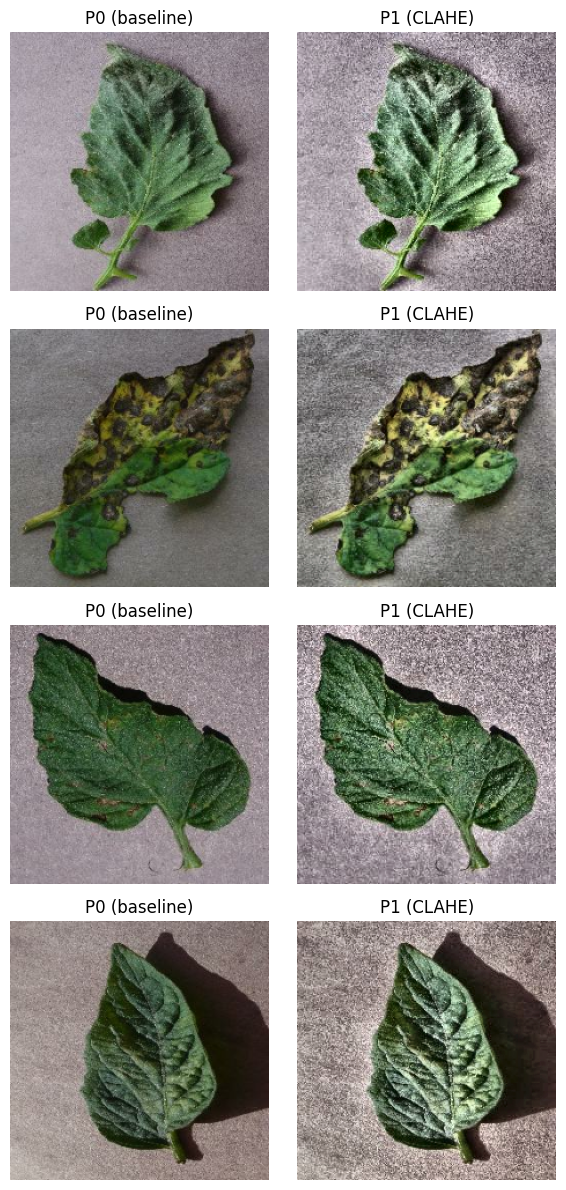

Saved preview to: /content/drive/MyDrive/PlantDiseaseProject/results/figures/p0_vs_p1_preview.png


In [ ]:
# Cell 13: Visual sanity check — plot a few examples through P0 and P1
import matplotlib.pyplot as plt

sample_paths = train_df["path"].sample(4, random_state=RANDOM_SEED).tolist()

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(6, 3 * len(sample_paths)))
for i, path in enumerate(sample_paths):
    img_p0 = load_image_p0(path).numpy()
    img_p1 = load_image_p1(path).numpy()
    axes[i, 0].imshow(img_p0)
    axes[i, 0].set_title("P0 (baseline)")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(img_p1)
    axes[i, 1].set_title("P1 (CLAHE)")
    axes[i, 1].axis("off")
plt.tight_layout()

fig_path = os.path.join(DRIVE_ROOT, 'results', 'figures', 'p0_vs_p1_preview.png')
plt.savefig(fig_path, dpi=100)
plt.show()
print("Saved preview to:", fig_path)

In [ ]:
# Cell 14 (updated): P2 preprocessing — wider background margin for GrabCut
P2_CONFIG = {
    "method": "grabcut",
    "pre_resize": [300, 300],
    "rect_margin_frac": 0.18,        # widened from 0.06 -> gives GrabCut a real background sample
    "iter_count": 8,                  # a few more refinement iterations
    "bbox_padding_frac": 0.05,
    "fallback_on_empty_mask": "use_full_image",
}

def _grabcut_crop_numpy(img_uint8):
    h, w = img_uint8.shape[:2]
    margin = P2_CONFIG["rect_margin_frac"]
    rect = (int(w * margin), int(h * margin), int(w * (1 - 2 * margin)), int(h * (1 - 2 * margin)))

    mask = np.zeros((h, w), np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    try:
        cv2.grabCut(img_uint8, mask, rect, bgd_model, fgd_model,
                    P2_CONFIG["iter_count"], cv2.GC_INIT_WITH_RECT)
        fg_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)
    except cv2.error:
        fg_mask = np.ones((h, w), np.uint8)

    ys, xs = np.where(fg_mask == 1)
    if len(ys) == 0:
        return img_uint8

    pad = P2_CONFIG["bbox_padding_frac"]
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    pad_y = int((y1 - y0) * pad)
    pad_x = int((x1 - x0) * pad)
    y0 = max(0, y0 - pad_y); y1 = min(h, y1 + pad_y)
    x0 = max(0, x0 - pad_x); x1 = min(w, x1 + pad_x)

    return img_uint8[y0:y1, x0:x1]

def load_image_p2(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, P2_CONFIG["pre_resize"])
    img_uint8 = tf.cast(img, tf.uint8)

    def grabcut_wrapper(x):
        return _grabcut_crop_numpy(x.numpy())

    cropped = tf.py_function(func=grabcut_wrapper, inp=[img_uint8], Tout=tf.uint8)
    cropped.set_shape([None, None, 3])
    final = tf.image.resize(cropped, IMAGE_SIZE)
    return final / 255.0

print("P2 (GrabCut) redefined with wider margin:", P2_CONFIG)

P2 (GrabCut) redefined with wider margin: {'method': 'grabcut', 'pre_resize': [300, 300], 'rect_margin_frac': 0.18, 'iter_count': 8, 'bbox_padding_frac': 0.05, 'fallback_on_empty_mask': 'use_full_image'}


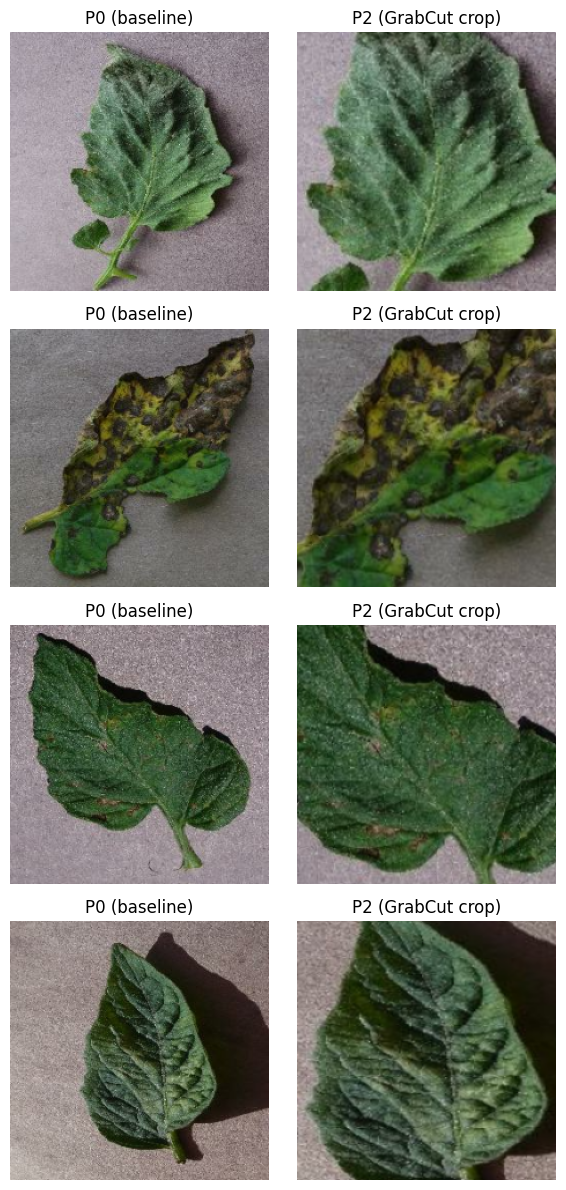

Saved preview to: /content/drive/MyDrive/PlantDiseaseProject/results/figures/p0_vs_p2_preview.png


In [ ]:
# Cell 15: Visual sanity check — P0 vs P2 (GrabCut leaf-focused crop)
sample_paths_p2 = train_df["path"].sample(4, random_state=RANDOM_SEED).tolist()

fig, axes = plt.subplots(len(sample_paths_p2), 2, figsize=(6, 3 * len(sample_paths_p2)))
for i, path in enumerate(sample_paths_p2):
    img_p0 = load_image_p0(path).numpy()
    img_p2 = load_image_p2(path).numpy()
    axes[i, 0].imshow(img_p0)
    axes[i, 0].set_title("P0 (baseline)")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(img_p2)
    axes[i, 1].set_title("P2 (GrabCut crop)")
    axes[i, 1].axis("off")
plt.tight_layout()

fig_path = os.path.join(DRIVE_ROOT, 'results', 'figures', 'p0_vs_p2_preview.png')
plt.savefig(fig_path, dpi=100)
plt.show()
print("Saved preview to:", fig_path)

In [ ]:
# Cell 16: Build tf.data.Dataset objects from split CSVs, with selectable preprocessing (P0/P1/P2)

PREPROCESSORS = {
    "P0": load_image_p0,
    "P1": load_image_p1,
    "P2": load_image_p2,
}

# Class name -> integer index mapping (alphabetical, deterministic — saved to config so it's never ambiguous)
CLASS_NAMES = sorted(train_df["class"].unique().tolist())
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
print("Class mapping (index : name):")
for name, idx in CLASS_TO_IDX.items():
    print(f"  {idx}: {name}")

# Augmentation layers — only applied to TRAINING data, never val/test/PlantCity
augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="augmentation")

AUGMENTATION_CONFIG = {
    "horizontal_flip": True,
    "rotation_range": 0.08,
    "zoom_range": 0.1,
    "contrast_range": 0.1,
}

def build_dataset(df, preprocessing_name, batch_size, shuffle=False, augment=False, seed=RANDOM_SEED):
    """
    df: DataFrame with 'path' and 'class' columns
    preprocessing_name: one of 'P0', 'P1', 'P2'
    Returns a batched, prefetched tf.data.Dataset yielding (image, label) pairs.
    """
    preprocess_fn = PREPROCESSORS[preprocessing_name]
    paths = df["path"].values
    labels = np.array([CLASS_TO_IDX[c] for c in df["class"].values])

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=seed, reshuffle_each_iteration=True)

    def _load(path, label):
        img = preprocess_fn(path)
        label = tf.one_hot(label, NUM_CLASSES)
        return img, label

    # P1/P2 use tf.py_function internally (OpenCV calls), which forces sequential execution
    # for those specific ops — this is expected and unavoidable with OpenCV in the loop.
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(lambda x, y: (augmentation_layer(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

print("\ntf.data pipeline builder ready.")

Class mapping (index : name):
  0: Tomato___Bacterial_spot
  1: Tomato___Early_blight
  2: Tomato___Late_blight
  3: Tomato___Leaf_Mold
  4: Tomato___Septoria_leaf_spot
  5: Tomato___Spider_mites Two-spotted_spider_mite
  6: Tomato___Target_Spot
  7: Tomato___Tomato_Yellow_Leaf_Curl_Virus
  8: Tomato___Tomato_mosaic_virus
  9: Tomato___healthy

tf.data pipeline builder ready.


In [ ]:
# Cell 17: Sanity test — build a tiny dataset and pull one batch through it
test_ds = build_dataset(train_df.sample(16, random_state=RANDOM_SEED),
                         preprocessing_name="P0", batch_size=8, shuffle=True, augment=True)

for images, labels in test_ds.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Pixel value range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Batch image shape: (8, 224, 224, 3)
Batch label shape: (8, 10)
Pixel value range: 0.0 to 0.9246010780334473


In [ ]:
# Cell 18: Centralized experiment logger
import time
from datetime import datetime, timezone

EXPERIMENT_LOG_PATH = os.path.join(DRIVE_ROOT, 'reports', 'experiment_log.csv')
EXPERIMENTS_DIR = os.path.join(DRIVE_ROOT, 'results', 'experiments')

LOG_COLUMNS = [
    "experiment_id", "timestamp", "dataset", "dataset_path", "model", "preprocessing",
    "augmentation", "random_seed", "image_size", "batch_size", "optimizer", "learning_rate",
    "scheduler", "weight_decay", "requested_epochs", "completed_epochs", "class_weighting",
    "train_loss", "validation_loss", "train_accuracy", "validation_accuracy",
    "train_macro_f1", "validation_macro_f1", "test_macro_f1", "PlantCity_macro_f1",
    "generalization_gap", "parameter_count", "model_size_mb", "inference_latency_ms",
    "checkpoint_path", "configuration_path", "experiment_status", "notes",
]
NOT_RUN = "NOT RUN"

class ExperimentLogger:
    def __init__(self, log_path, columns):
        self.log_path = log_path
        self.columns = columns
        if not os.path.exists(self.log_path):
            pd.DataFrame(columns=self.columns).to_csv(self.log_path, index=False)

    def _next_id(self):
        df = pd.read_csv(self.log_path)
        if len(df) == 0:
            return "EXP_0001"
        nums = df["experiment_id"].str.extract(r'EXP_(\d+)').astype(int)[0]
        return f"EXP_{nums.max() + 1:04d}"

    def _blank_row(self):
        return {col: NOT_RUN for col in self.columns}

    def _write_row(self, row_dict):
        df = pd.read_csv(self.log_path)
        exp_id = row_dict["experiment_id"]
        if exp_id in df["experiment_id"].values:
            idx = df.index[df["experiment_id"] == exp_id][0]
            for k, v in row_dict.items():
                df.loc[idx, k] = v
        else:
            df = pd.concat([df, pd.DataFrame([row_dict])], ignore_index=True)
        df.to_csv(self.log_path, index=False)

    def start(self, config: dict) -> str:
        exp_id = self._next_id()
        row = self._blank_row()
        row.update({
            "experiment_id": exp_id,
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "dataset": config.get("dataset", NOT_RUN),
            "dataset_path": config.get("dataset_path", NOT_RUN),
            "model": config.get("model", NOT_RUN),
            "preprocessing": config.get("preprocessing", NOT_RUN),
            "augmentation": json.dumps(config.get("augmentation", {})),
            "random_seed": config.get("random_seed", NOT_RUN),
            "image_size": str(config.get("image_size", NOT_RUN)),
            "batch_size": config.get("batch_size", NOT_RUN),
            "optimizer": config.get("optimizer", NOT_RUN),
            "learning_rate": config.get("learning_rate", NOT_RUN),
            "scheduler": config.get("scheduler", NOT_RUN),
            "weight_decay": config.get("weight_decay", NOT_RUN),
            "requested_epochs": config.get("requested_epochs", NOT_RUN),
            "completed_epochs": 0,
            "class_weighting": config.get("class_weighting", NOT_RUN),
            "experiment_status": "RUNNING",
        })
        self._write_row(row)

        exp_dir = os.path.join(EXPERIMENTS_DIR, exp_id)
        os.makedirs(exp_dir, exist_ok=True)
        config_path = os.path.join(exp_dir, 'config.json')
        with open(config_path, 'w') as f:
            json.dump({**config, "experiment_id": exp_id}, f, indent=2)

        self._write_row({**row, "configuration_path": config_path})
        print(f"Started {exp_id} — config saved to {config_path}")
        return exp_id

    def update(self, exp_id, **kwargs):
        row = self._blank_row()
        row["experiment_id"] = exp_id
        df = pd.read_csv(self.log_path)
        existing = df[df["experiment_id"] == exp_id].iloc[0].to_dict()
        existing.update(kwargs)
        self._write_row(existing)

    def complete(self, exp_id, **final_metrics):
        self.update(exp_id, experiment_status="COMPLETED", **final_metrics)
        print(f"{exp_id} marked COMPLETED")

    def fail(self, exp_id, reason, last_epoch=None, checkpoint_path=None):
        updates = {"experiment_status": "FAILED", "notes": f"FAILED: {reason}"}
        if last_epoch is not None:
            updates["completed_epochs"] = last_epoch
        if checkpoint_path is not None:
            updates["checkpoint_path"] = checkpoint_path
        self.update(exp_id, **updates)
        print(f"{exp_id} marked FAILED: {reason}")

    def skip(self, exp_id, reason):
        self.update(exp_id, experiment_status="SKIPPED", notes=f"SKIPPED: {reason}")
        print(f"{exp_id} marked SKIPPED: {reason}")


logger = ExperimentLogger(EXPERIMENT_LOG_PATH, LOG_COLUMNS)
os.makedirs(EXPERIMENTS_DIR, exist_ok=True)
print("Experiment logger ready. Log file:", EXPERIMENT_LOG_PATH)

Experiment logger ready. Log file: /content/drive/MyDrive/PlantDiseaseProject/reports/experiment_log.csv


In [ ]:
# Cell 19: Keras callback that updates the experiment logger after every epoch
# This is what guarantees "no lost data on interruption" — every epoch writes immediately.

class ExperimentLoggerCallback(tf.keras.callbacks.Callback):
    def __init__(self, logger, exp_id, history_csv_path):
        super().__init__()
        self.logger = logger
        self.exp_id = exp_id
        self.history_csv_path = history_csv_path
        self.history_rows = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        row = {"epoch": epoch + 1, **logs}
        self.history_rows.append(row)
        pd.DataFrame(self.history_rows).to_csv(self.history_csv_path, index=False)

        self.logger.update(
            self.exp_id,
            completed_epochs=epoch + 1,
            train_loss=logs.get("loss", NOT_RUN),
            validation_loss=logs.get("val_loss", NOT_RUN),
            train_accuracy=logs.get("accuracy", NOT_RUN),
            validation_accuracy=logs.get("val_accuracy", NOT_RUN),
        )

print("ExperimentLoggerCallback defined.")

ExperimentLoggerCallback defined.


In [ ]:
# Cell 20: Model definitions — Custom CNN, ResNet-18 (from scratch), MobileNetV3-Small, DenseNet-121
from tensorflow.keras import layers, models

INPUT_SHAPE = (*IMAGE_SIZE, 3)

# ---------- 1. Custom CNN (simple baseline, no pretraining) ----------
def build_custom_cnn(num_classes=NUM_CLASSES, input_shape=INPUT_SHAPE):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs, name="custom_cnn")
    return model, {"pretrained": False, "frozen_layers": 0, "finetune_status": "from_scratch"}

# ---------- 2. ResNet-18 (implemented from scratch — Keras has no built-in ResNet-18) ----------
def _resnet_basic_block(x, filters, stride=1, downsample=False):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if downsample:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def build_resnet18(num_classes=NUM_CLASSES, input_shape=INPUT_SHAPE):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    filters_per_stage = [64, 128, 256, 512]
    for stage_idx, filters in enumerate(filters_per_stage):
        for block_idx in range(2):
            stride = 2 if (block_idx == 0 and stage_idx > 0) else 1
            downsample = (block_idx == 0 and stage_idx > 0)
            x = _resnet_basic_block(x, filters, stride=stride, downsample=downsample)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs, name="resnet18_scratch")
    return model, {"pretrained": False, "frozen_layers": 0, "finetune_status": "from_scratch"}

# ---------- 3. MobileNetV3-Small (ImageNet pretrained, configurable fine-tune strategy) ----------
def build_mobilenetv3_small(num_classes=NUM_CLASSES, input_shape=INPUT_SHAPE, finetune_status="frozen"):
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg',
        include_preprocessing=False  # FIX: our pipeline already normalizes to [0,1]
    )
    if finetune_status == "frozen":
        base.trainable = False
    elif finetune_status == "partial_finetune":
        base.trainable = True
        for layer in base.layers[:-20]:
            layer.trainable = False
    elif finetune_status == "full_finetune":
        base.trainable = True

    x = base.output
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(base.input, outputs, name="mobilenetv3_small")
    frozen_count = sum(1 for l in base.layers if not l.trainable)
    return model, {"pretrained": True, "frozen_layers": frozen_count, "finetune_status": finetune_status}

# ---------- 4. DenseNet-121 (ImageNet pretrained, configurable fine-tune strategy) ----------
def build_densenet121(num_classes=NUM_CLASSES, input_shape=INPUT_SHAPE, finetune_status="frozen"):
    base = tf.keras.applications.DenseNet121(   # FIXED: was accidentally MobileNetV3Small
        input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg'
    )
    if finetune_status == "frozen":
        base.trainable = False
    elif finetune_status == "partial_finetune":
        base.trainable = True
        for layer in base.layers[:-30]:
            layer.trainable = False
    elif finetune_status == "full_finetune":
        base.trainable = True

    x = base.output
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(base.input, outputs, name="densenet121")
    frozen_count = sum(1 for l in base.layers if not l.trainable)
    return model, {"pretrained": True, "frozen_layers": frozen_count, "finetune_status": finetune_status}


MODEL_BUILDERS = {
    "custom_cnn": build_custom_cnn,
    "resnet18": build_resnet18,
    "mobilenetv3_small": build_mobilenetv3_small,
    "densenet121": build_densenet121,
}

print("Model builders defined:", list(MODEL_BUILDERS.keys()))

Model builders defined: ['custom_cnn', 'resnet18', 'mobilenetv3_small', 'densenet121']


In [ ]:
m1, _ = MODEL_BUILDERS["densenet121"]()
m2, _ = MODEL_BUILDERS["mobilenetv3_small"]()
print("densenet121 params:", m1.count_params(), "| mobilenetv3_small params:", m2.count_params())
del m1, m2

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
densenet121 params: 7047754 | mobilenetv3_small params: 944890


In [ ]:
# Cell 21: Sanity check all four models build correctly, report param counts (never hand-typed)
for name, builder in MODEL_BUILDERS.items():
    model, meta = builder()
    total_params = model.count_params()
    trainable_params = sum(np.prod(v.shape) for v in model.trainable_weights)
    print(f"{name:20s} | total params: {total_params:>10,} | trainable: {trainable_params:>10,} | pretrained: {meta['pretrained']}")
    del model  # free memory before building the next one

custom_cnn           | total params:  1,242,538 | trainable:  1,241,578 | pretrained: False
resnet18             | total params: 11,191,242 | trainable: 11,181,642 | pretrained: False
mobilenetv3_small    | total params:    944,890 | trainable:      5,770 | pretrained: True
densenet121          | total params:  7,047,754 | trainable:     10,250 | pretrained: True


In [ ]:
# Cell 22: Experiment modes and the main training function

EXPERIMENT_MODES = {
    "DEBUG": {"subset_per_class": 20, "epochs": 2, "batch_size": 8},
    "PILOT": {"subset_frac": 0.2, "epochs": 8, "batch_size": 16},
    "FULL":  {"subset_frac": 1.0, "epochs": 30, "batch_size": 32},
}

# SAFETY: default mode for the notebook is DEBUG. You must explicitly change this
# variable and re-run to do anything expensive.
CURRENT_MODE = "DEBUG"
print(f"Current experiment mode: {CURRENT_MODE}  (change CURRENT_MODE and re-run to switch)")

from sklearn.metrics import f1_score
import time

def compute_macro_f1(model, dataset, num_classes):
    y_true_all, y_pred_all = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred_all.extend(np.argmax(preds, axis=1))
        y_true_all.extend(np.argmax(labels.numpy(), axis=1))
    return f1_score(y_true_all, y_pred_all, average='macro', labels=list(range(num_classes)))

def measure_inference_latency(model, sample_batch, n_runs=20):
    # warm-up (first call includes graph tracing overhead, exclude from timing)
    _ = model.predict(sample_batch, verbose=0)
    start = time.time()
    for _ in range(n_runs):
        _ = model.predict(sample_batch, verbose=0)
    elapsed = time.time() - start
    return (elapsed / n_runs) * 1000  # ms per batch call

def get_subset(df, mode_config, seed=RANDOM_SEED):
    if "subset_per_class" in mode_config:
        n = mode_config["subset_per_class"]
        return df.groupby("class", group_keys=False).apply(
            lambda g: g.sample(min(n, len(g)), random_state=seed)
        ).reset_index(drop=True)
    else:
        frac = mode_config.get("subset_frac", 1.0)
        if frac >= 1.0:
            return df
        return df.groupby("class", group_keys=False).apply(
            lambda g: g.sample(frac=frac, random_state=seed)
        ).reset_index(drop=True)

def run_experiment(model_name, preprocessing_name, mode=None, finetune_status="frozen",
                    class_weighting=False, learning_rate=1e-3, optimizer_name="adam",
                    notes=""):
    mode = mode or CURRENT_MODE
    mode_config = EXPERIMENT_MODES[mode]

    train_subset = get_subset(train_df, mode_config)
    val_subset = get_subset(val_df, mode_config)

    config = {
        "dataset": "PlantVillage",
        "dataset_path": pv_color_path,
        "model": model_name,
        "preprocessing": preprocessing_name,
        "augmentation": AUGMENTATION_CONFIG,
        "random_seed": RANDOM_SEED,
        "image_size": list(IMAGE_SIZE),
        "batch_size": mode_config["batch_size"],
        "optimizer": optimizer_name,
        "learning_rate": learning_rate,
        "scheduler": "none",
        "weight_decay": 0.0,
        "requested_epochs": mode_config["epochs"],
        "class_weighting": class_weighting,
        "num_workers": "tf.data.AUTOTUNE",
        "early_stopping": {"patience": 5, "monitor": "val_loss"},
        "mode": mode,
        "class_mapping": CLASS_TO_IDX,
        "notes": notes,
    }

    exp_id = logger.start(config)
    exp_dir = os.path.join(EXPERIMENTS_DIR, exp_id)

    try:
        train_ds = build_dataset(train_subset, preprocessing_name, mode_config["batch_size"],
                                  shuffle=True, augment=True)
        val_ds = build_dataset(val_subset, preprocessing_name, mode_config["batch_size"],
                                shuffle=False, augment=False)

        builder = MODEL_BUILDERS[model_name]
        if model_name in ("mobilenetv3_small", "densenet121"):
            model, model_meta = builder(finetune_status=finetune_status)
        else:
            model, model_meta = builder()
        config.update(model_meta)

        class_weights = None
        if class_weighting:
            counts = train_subset["class"].value_counts()
            total = counts.sum()
            class_weights = {CLASS_TO_IDX[c]: total / (NUM_CLASSES * counts[c]) for c in counts.index}

        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate) if optimizer_name == "adam" \
              else tf.keras.optimizers.SGD(learning_rate=learning_rate)
        model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

        checkpoint_best_path = os.path.join(exp_dir, 'checkpoint_best.keras')
        checkpoint_final_path = os.path.join(exp_dir, 'checkpoint_final.keras')
        history_csv_path = os.path.join(exp_dir, 'training_history.csv')

        callbacks = [
            ExperimentLoggerCallback(logger, exp_id, history_csv_path),
            tf.keras.callbacks.ModelCheckpoint(checkpoint_best_path, save_best_only=True,
                                                monitor='val_loss', mode='min'),
            tf.keras.callbacks.EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
        ]

        history = model.fit(
            train_ds, validation_data=val_ds, epochs=mode_config["epochs"],
            callbacks=callbacks, class_weight=class_weights, verbose=1,
        )
        model.save(checkpoint_final_path)  # required artifact: weights at end of training

        # FIX: EarlyStopping only restores best weights when it actually triggers a stop.
        # If training completes the full epoch budget without triggering, `model` still holds
        # the LAST epoch's weights, not the best one. Reload the best checkpoint explicitly so
        # every reported metric reflects the best model, not whatever epoch training ended on.
        model = tf.keras.models.load_model(checkpoint_best_path)

        train_f1 = compute_macro_f1(model, train_ds, NUM_CLASSES)
        val_f1 = compute_macro_f1(model, val_ds, NUM_CLASSES)

        sample_batch = next(iter(val_ds))[0]
        latency_ms = measure_inference_latency(model, sample_batch)
        model_size_mb = os.path.getsize(checkpoint_best_path) / (1024 ** 2)

        logger.complete(
            exp_id,
            train_macro_f1=train_f1,
            validation_macro_f1=val_f1,
            parameter_count=model.count_params(),
            model_size_mb=round(model_size_mb, 3),
            inference_latency_ms=round(latency_ms, 3),
            checkpoint_path=checkpoint_best_path,
        )
        print(f"\n{exp_id} COMPLETE — val_macro_f1={val_f1:.4f}, latency={latency_ms:.1f}ms/batch, size={model_size_mb:.2f}MB")
        return exp_id, model

    except Exception as e:
        last_epoch = 0
        try:
            hist_df = pd.read_csv(os.path.join(exp_dir, 'training_history.csv'))
            last_epoch = len(hist_df)
        except FileNotFoundError:
            pass
        logger.fail(exp_id, reason=str(e), last_epoch=last_epoch)
        raise

print("run_experiment() ready (checkpoint-selection bug fixed).")

Current experiment mode: DEBUG  (change CURRENT_MODE and re-run to switch)
run_experiment() ready (checkpoint-selection bug fixed).


In [ ]:
# Cell 23: First real test — EXP_0001, DEBUG mode, custom CNN, P0 preprocessing
exp_id, model = run_experiment(
    model_name="custom_cnn",
    preprocessing_name="P0",
    mode="DEBUG",
    notes="First pipeline smoke test — DEBUG mode, tiny subset, verifying the full loop end to end."
)

/tmp/ipykernel_1444/1077540883.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("class", group_keys=False).apply(
/tmp/ipykernel_1444/1077540883.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("class", group_keys=False).apply(


Started EXP_0011 — config saved to /content/drive/MyDrive/PlantDiseaseProject/results/experiments/EXP_0011/config.json
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 143s 5s/step - accuracy: 0.1450 - loss: 2.7643 - val_accuracy: 0.1000 - val_loss: 2.3540
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 133s 5s/step - accuracy: 0.2000 - loss: 2.2562 - val_accuracy: 0.1100 - val_loss: 2.4599
EXP_0011 marked COMPLETED

EXP_0011 COMPLETE — val_macro_f1=0.0182, latency=1232.5ms/batch, size=14.31MB


In [ ]:
# Cell 24: EXP_0002 — PILOT mode, custom CNN, P0 preprocessing
# This uses 20% of the full dataset and trains for up to 8 epochs (with early stopping),
# so expect several minutes on Colab's GPU, not seconds.

exp_id_2, model_2 = run_experiment(
    model_name="custom_cnn",
    preprocessing_name="P0",
    mode="PILOT",
    notes="First real PILOT run — checking that meaningful learning happens before scaling to all combinations."
)

NameError: name 'run_experiment' is not defined

In [ ]:
# Cell 25: Document the bug's effect on EXP_0002 (audit trail, not deletion), then re-run corrected
logger.update("EXP_0002", notes="Metrics computed on final-epoch (not best-checkpoint) weights due to a "
                                  "since-fixed bug in run_experiment(); best checkpoint (epoch 5, val_loss=1.48) "
                                  "was saved correctly to disk but not used for reported metrics. Superseded by EXP_0003.")
print("EXP_0002 annotated.")

In [ ]:
# Cell 26: EXP_0003 — same config as EXP_0002, with the checkpoint-selection bug fixed
exp_id_3, model_3 = run_experiment(
    model_name="custom_cnn",
    preprocessing_name="P0",
    mode="PILOT",
    notes="Repeat of EXP_0002 with checkpoint-selection bug fixed — now reports best-epoch metrics."
)

In [ ]:
# Cell 27: Confirm which epoch's weights are actually loaded after run_experiment finishes
history_df = pd.read_csv(os.path.join(EXPERIMENTS_DIR, "EXP_0003", "training_history.csv"))
best_epoch_row = history_df.loc[history_df["val_loss"].idxmin()]
print("Best epoch by val_loss (what ModelCheckpoint should have saved):")
print(best_epoch_row)

# Re-evaluate the currently loaded `model_3` object directly to compare
val_ds_check = build_dataset(get_subset(val_df, EXPERIMENT_MODES["PILOT"]), "P0", 16, shuffle=False, augment=False)
loss, acc = model_3.evaluate(val_ds_check, verbose=0)
print(f"\nmodel_3 (should be best checkpoint) val_accuracy: {acc:.4f}, val_loss: {loss:.4f}")
print(f"Compare to best_epoch_row val_accuracy: {best_epoch_row['val_accuracy']:.4f}")

In [ ]:
# Cell 28: FULL-mode training — final candidates only
combos_full = [
    ("mobilenetv3_small", "P2"),
    ("densenet121", "P0"),
]

results_summary = []

for model_name, prep_name in combos_full:
    print(f"\n{'='*60}\nFULL-mode training: {model_name} + {prep_name}\n{'='*60}")
    try:
        exp_id, trained_model = run_experiment(
            model_name=model_name,
            preprocessing_name=prep_name,
            mode="FULL",
            notes=f"FULL-mode training — selected as best PILOT candidate for {model_name}"
        )
        results_summary.append({"experiment_id": exp_id, "model": model_name,
                                 "preprocessing": prep_name, "status": "COMPLETED"})
    except Exception as e:
        print(f"FAILED: {model_name} + {prep_name} -> {e}")
        results_summary.append({"experiment_id": None, "model": model_name,
                                 "preprocessing": prep_name, "status": "FAILED", "error": str(e)})
        continue

print("\n\n=== FULL-mode batch summary ===")
for r in results_summary:
    print(r)


FULL-mode training: mobilenetv3_small + P2
Started EXP_0029 — config saved to /content/drive/MyDrive/PlantDiseaseProject/results/experiments/EXP_0029/config.json
Epoch 1/30
EXP_0029 marked FAILED: Graph execution error:

Detected at node EagerPyFunc defined at (most recent call last):
<stack traces unavailable>
Detected at node EagerPyFunc defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) UNKNOWN:  Error in user-defined function passed to ParallelMapDatasetV2:9079 transformation with iterator: Iterator::Root::Prefetch::MapAndBatch::ParallelMapV2: FileNotFoundError: [Errno 2] No such file or directory: '/content/data/p2_cache/fe63a1b1bbd32f183dec9b194bcf4b7a.jpg'
Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/tensorflow/python/ops/script_ops.py", line 267, in __call__
    return func(device, token, args)

  File "/usr/local/lib/python3.13/dist-packages/tensorflow/python/ops/script_ops.py", line 145, in __cal

In [ ]:
# Cell 28a (fixed): Precompute GrabCut results, with defensive handling for edge cases
import hashlib
from PIL import Image as PILImage
from concurrent.futures import ThreadPoolExecutor
import time

P2_CACHE_DIR = os.path.join(LOCAL_ROOT, 'p2_cache')
os.makedirs(P2_CACHE_DIR, exist_ok=True)

def p2_cache_path_for(original_path):
    h = hashlib.md5(original_path.encode()).hexdigest()
    return os.path.join(P2_CACHE_DIR, f"{h}.jpg")

def _grabcut_crop_numpy_safe(img_uint8):
    """Same as before, but guards against a degenerate (zero-size) crop."""
    h, w = img_uint8.shape[:2]
    margin = P2_CONFIG["rect_margin_frac"]
    rect = (int(w * margin), int(h * margin), int(w * (1 - 2 * margin)), int(h * (1 - 2 * margin)))

    mask = np.zeros((h, w), np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    try:
        cv2.grabCut(img_uint8, mask, rect, bgd_model, fgd_model,
                    P2_CONFIG["iter_count"], cv2.GC_INIT_WITH_RECT)
        fg_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)
    except cv2.error:
        return img_uint8  # GrabCut itself failed -> use full image, definitely non-empty

    ys, xs = np.where(fg_mask == 1)
    if len(ys) == 0:
        return img_uint8  # no foreground found -> full image

    pad = P2_CONFIG["bbox_padding_frac"]
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    pad_y = int((y1 - y0) * pad)
    pad_x = int((x1 - x0) * pad)
    y0 = max(0, y0 - pad_y); y1 = min(h, y1 + pad_y)
    x0 = max(0, x0 - pad_x); x1 = min(w, x1 + pad_x)

    # FIX: guard against a degenerate (zero-height or zero-width) crop
    if y1 <= y0 or x1 <= x0:
        return img_uint8  # fall back to full image rather than producing an empty array

    cropped = img_uint8[y0:y1, x0:x1]
    if cropped.size == 0:  # belt-and-suspenders check
        return img_uint8
    return cropped

failed_paths = []  # audit trail — never silently drop a problematic file

def _precompute_one(path):
    cache_path = p2_cache_path_for(path)
    if os.path.exists(cache_path):
        return
    try:
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, P2_CONFIG["pre_resize"])
        img_uint8 = tf.cast(img, tf.uint8).numpy()
        cropped = _grabcut_crop_numpy_safe(img_uint8)
        PILImage.fromarray(cropped).save(cache_path, quality=95)
    except Exception as e:
        # FIX: don't let one bad file crash the whole batch — log it and fall back
        # to the plain resized image (still usable for training) instead of leaving
        # this path uncached (which would break the loader later).
        failed_paths.append({"path": path, "error": str(e)})
        try:
            img = tf.io.read_file(path)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, P2_CONFIG["pre_resize"])
            PILImage.fromarray(tf.cast(img, tf.uint8).numpy()).save(cache_path, quality=95)
        except Exception as e2:
            failed_paths.append({"path": path, "error": f"fallback also failed: {e2}"})

pilot_train_subset = get_subset(train_df, EXPERIMENT_MODES["PILOT"])
pilot_val_subset = get_subset(val_df, EXPERIMENT_MODES["PILOT"])
paths_to_cache = list(pilot_train_subset["path"]) + list(pilot_val_subset["path"])
print(f"Caching P2 output for {len(paths_to_cache)} images (train+val PILOT subset)...")

start = time.time()
with ThreadPoolExecutor(max_workers=8) as executor:
    list(executor.map(_precompute_one, paths_to_cache))
elapsed = time.time() - start

print(f"Done in {elapsed/60:.1f} minutes. Cached files: {len(os.listdir(P2_CACHE_DIR))}")
if failed_paths:
    print(f"\n{len(failed_paths)} images hit an issue during GrabCut (fell back to uncropped resize):")
    for f in failed_paths[:10]:
        print(f"  {f['path']}: {f['error']}")
    # Save this as a proper audit record, per your spec's "never silently exclude" rule
    pd.DataFrame(failed_paths).to_csv(os.path.join(DRIVE_ROOT, 'reports', 'p2_cache_fallback_log.csv'), index=False)
    print(f"\nFull list saved to reports/p2_cache_fallback_log.csv")
else:
    print("No issues encountered.")

/tmp/ipykernel_1941/1077540883.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("class", group_keys=False).apply(
/tmp/ipykernel_1941/1077540883.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("class", group_keys=False).apply(


Caching P2 output for 3086 images (train+val PILOT subset)...
Done in 28.4 minutes. Cached files: 3086
No issues encountered.


In [ ]:
# Cell 28b: P2 loader now reads cached GrabCut output instead of recomputing it live
def load_image_p2(path):
    def _load_cached(p):
        p_str = p.numpy().decode('utf-8')
        cache_path = p2_cache_path_for(p_str)
        img = np.array(PILImage.open(cache_path).convert('RGB'))
        return img

    img = tf.py_function(func=_load_cached, inp=[path], Tout=tf.uint8)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMAGE_SIZE)
    return img / 255.0

# Re-register in the dispatcher (PREPROCESSORS dict already points to load_image_p2 by name,
# but since we just redefined the function object, re-run this line to be certain it's current)
PREPROCESSORS["P2"] = load_image_p2
print("P2 loader now cache-based — should be as fast as P0/P1 during training.")

P2 loader now cache-based — should be as fast as P0/P1 during training.


In [ ]:
df = pd.read_csv(EXPERIMENT_LOG_PATH)
running = df[df["experiment_status"] == "RUNNING"]
print(running[["experiment_id", "model", "preprocessing", "completed_epochs"]])

   experiment_id        model preprocessing  completed_epochs
11      EXP_0012   custom_cnn            P0                 0
12      EXP_0013   custom_cnn            P0                 0
29      EXP_0030  densenet121            P0                15


In [ ]:
exp_id = "EXP_0030"
exp_dir = os.path.join(EXPERIMENTS_DIR, exp_id)
checkpoint_best_path = os.path.join(exp_dir, 'checkpoint_best.keras')

# Load the best-so-far weights (epoch 14, val_loss=0.3134) — this is real, saved data, not lost
model = tf.keras.models.load_model(checkpoint_best_path)
print(f"Loaded checkpoint from {checkpoint_best_path}")

# Rebuild the validation set exactly as FULL mode would (full val_df, P0 preprocessing)
val_ds_final = build_dataset(val_df, "P0", EXPERIMENT_MODES["FULL"]["batch_size"], shuffle=False, augment=False)

# Compute the real final metrics on this checkpoint
val_f1 = compute_macro_f1(model, val_ds_final, NUM_CLASSES)
sample_batch = next(iter(val_ds_final))[0]
latency_ms = measure_inference_latency(model, sample_batch)
model_size_mb = os.path.getsize(checkpoint_best_path) / (1024 ** 2)

print(f"val_macro_f1: {val_f1:.4f}, latency: {latency_ms:.1f}ms/batch, size: {model_size_mb:.2f}MB")

# Finalize the log entry — honest about what happened, not silently treated as a full success
logger.complete(
    exp_id,
    validation_macro_f1=val_f1,
    parameter_count=model.count_params(),
    model_size_mb=round(model_size_mb, 3),
    inference_latency_ms=round(latency_ms, 3),
    checkpoint_path=checkpoint_best_path,
    completed_epochs=14,
    notes="GPU session disconnected during epoch 15/30 (resource limit reached). Manually finalized "
          "using the best checkpoint (epoch 14, val_loss=0.3134) rather than resuming, since the loss "
          "curve had clearly plateaued over the preceding 6 epochs (val_loss 0.31-0.39 range, no further "
          "meaningful improvement observed)."
)
print(f"\n{exp_id} finalized.")

Loaded checkpoint from /content/drive/MyDrive/PlantDiseaseProject/results/experiments/EXP_0030/checkpoint_best.keras
val_macro_f1: 0.8469, latency: 185.3ms/batch, size: 28.40MB
EXP_0030 marked COMPLETED

EXP_0030 finalized.


In [ ]:
combos_full = [("mobilenetv3_small", "P1")]

results_summary = []
for model_name, prep_name in combos_full:
    print(f"\n{'='*60}\nFULL-mode training: {model_name} + {prep_name}\n{'='*60}")
    try:
        exp_id, trained_model = run_experiment(
            model_name=model_name, preprocessing_name=prep_name, mode="FULL",
            notes="FULL-mode training — switched from P2 to P1 to avoid extending P2 cache to full dataset scale"
        )
        results_summary.append({"experiment_id": exp_id, "model": model_name, "preprocessing": prep_name, "status": "COMPLETED"})
    except Exception as e:
        print(f"FAILED: {model_name} + {prep_name} -> {e}")
        results_summary.append({"experiment_id": None, "model": model_name, "preprocessing": prep_name, "status": "FAILED", "error": str(e)})

print("\n=== Summary ===")
for r in results_summary:
    print(r)


FULL-mode training: mobilenetv3_small + P1
Started EXP_0032 — config saved to /content/drive/MyDrive/PlantDiseaseProject/results/experiments/EXP_0032/config.json
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 212s 495ms/step - accuracy: 0.6246 - loss: 1.1546 - val_accuracy: 0.7965 - val_loss: 0.6607
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 172s 434ms/step - accuracy: 0.7895 - loss: 0.6616 - val_accuracy: 0.8421 - val_loss: 0.5083
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 173s 435ms/step - accuracy: 0.8288 - loss: 0.5431 - val_accuracy: 0.8432 - val_loss: 0.4716
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 202s 435ms/step - accuracy: 0.8410 - loss: 0.4941 - val_accuracy: 0.8788 - val_loss: 0.4063
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 177s 444ms/step - accuracy: 0.8538 - loss: 0.4578 - val_accuracy: 0.8854 - val_loss: 0.3790
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 200s 439ms/step - accuracy: 0.8633 - loss: 0.4273 - val_accuracy: 0.8880 - val_loss: 0.3502
Epoch 7/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 173s 

In [ ]:
df = pd.read_csv(EXPERIMENT_LOG_PATH)
running = df[df["experiment_status"] == "RUNNING"]
print(running[["experiment_id", "model", "preprocessing", "completed_epochs"]])

   experiment_id       model preprocessing  completed_epochs
11      EXP_0012  custom_cnn            P0                 0
12      EXP_0013  custom_cnn            P0                 0


In [ ]:
exp_id = "EXP_0032"
exp_dir = os.path.join(EXPERIMENTS_DIR, exp_id)
checkpoint_best_path = os.path.join(exp_dir, 'checkpoint_best.keras')

# Check what actually happened — don't assume, read the real history
history_df = pd.read_csv(os.path.join(exp_dir, 'training_history.csv'))
best_row = history_df.loc[history_df["val_loss"].idxmin()]
print("Best epoch by val_loss:")
print(best_row)
print(f"\nTotal epochs completed: {len(history_df)}")

Best epoch by val_loss:
epoch           16.000000
accuracy         0.881918
loss             0.350723
val_accuracy     0.911127
val_loss         0.281312
Name: 15, dtype: float64

Total epochs completed: 16


In [ ]:
model = tf.keras.models.load_model(checkpoint_best_path)
print(f"Loaded checkpoint from {checkpoint_best_path}")

val_ds_final = build_dataset(val_df, "P1", EXPERIMENT_MODES["FULL"]["batch_size"], shuffle=False, augment=False)

val_f1 = compute_macro_f1(model, val_ds_final, NUM_CLASSES)
sample_batch = next(iter(val_ds_final))[0]
latency_ms = measure_inference_latency(model, sample_batch)
model_size_mb = os.path.getsize(checkpoint_best_path) / (1024 ** 2)

print(f"val_macro_f1: {val_f1:.4f}, latency: {latency_ms:.1f}ms/batch, size: {model_size_mb:.2f}MB")

logger.complete(
    "EXP_0032",
    validation_macro_f1=val_f1,
    parameter_count=model.count_params(),
    model_size_mb=round(model_size_mb, 3),
    inference_latency_ms=round(latency_ms, 3),
    checkpoint_path=checkpoint_best_path,
    completed_epochs=16,
    notes="GPU session disconnected after epoch 16/30. Manually finalized using the best checkpoint "
          "(epoch 16, val_loss=0.2813, val_accuracy=0.911) — the strongest epoch reached before the "
          "disconnect, per the training_history.csv record."
)
print("\nEXP_0032 finalized.")

Loaded checkpoint from /content/drive/MyDrive/PlantDiseaseProject/results/experiments/EXP_0032/checkpoint_best.keras
val_macro_f1: 0.8836, latency: 93.0ms/batch, size: 4.19MB
EXP_0032 marked COMPLETED

EXP_0032 finalized.


In [ ]:
# Cell 33: PlantVillage test-set evaluation — the untouched held-out split, used exactly once per model
test_results = {}

candidates = [
    {"exp_id": "EXP_0030", "model": "densenet121", "preprocessing": "P0"},
    {"exp_id": "EXP_0032", "model": "mobilenetv3_small", "preprocessing": "P1"},
]

for c in candidates:
    exp_id = c["exp_id"]
    checkpoint_path = os.path.join(EXPERIMENTS_DIR, exp_id, 'checkpoint_best.keras')
    print(f"\n{'='*60}\nEvaluating {exp_id} ({c['model']} + {c['preprocessing']}) on PlantVillage TEST set\n{'='*60}")

    model = tf.keras.models.load_model(checkpoint_path)
    test_ds = build_dataset(test_df, c["preprocessing"], EXPERIMENT_MODES["FULL"]["batch_size"],
                             shuffle=False, augment=False)

    test_f1 = compute_macro_f1(model, test_ds, NUM_CLASSES)
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"Test macro-F1: {test_f1:.4f} | Test accuracy: {test_accuracy:.4f} | Test loss: {test_loss:.4f}")

    logger.update(exp_id, test_macro_f1=test_f1)
    test_results[exp_id] = {"model": c["model"], "preprocessing": c["preprocessing"],
                             "test_macro_f1": test_f1, "test_accuracy": test_accuracy}
    del model

print("\n\n=== PlantVillage Test Results Summary ===")
for exp_id, r in test_results.items():
    print(f"{exp_id} ({r['model']}+{r['preprocessing']}): test_macro_f1={r['test_macro_f1']:.4f}, test_accuracy={r['test_accuracy']:.4f}")


Evaluating EXP_0030 (densenet121 + P0) on PlantVillage TEST set
Test macro-F1: 0.8629 | Test accuracy: 0.8926 | Test loss: 0.3190

Evaluating EXP_0032 (mobilenetv3_small + P1) on PlantVillage TEST set
Test macro-F1: 0.8797 | Test accuracy: 0.9055 | Test loss: 0.3031


=== PlantVillage Test Results Summary ===
EXP_0030 (densenet121+P0): test_macro_f1=0.8629, test_accuracy=0.8926
EXP_0032 (mobilenetv3_small+P1): test_macro_f1=0.8797, test_accuracy=0.9055


In [ ]:
# Cell 34: Build PlantCity dataset restricted to the 7 shared classes, mapped to PlantVillage's class indices
shared_map = {s["plantcity"]: s["plantvillage"] for s in class_mapping["shared_classes"]}
print("PlantCity folder -> PlantVillage class mapping:")
for k, v in shared_map.items():
    print(f"  {k} -> {v}")

# Scan PlantCity, keep only files in the 7 shared folders, relabel with the PlantVillage class name
pc_records = []
for pc_class, pv_class in shared_map.items():
    pc_class_path = os.path.join(pc_test_path, pc_class)
    if not os.path.isdir(pc_class_path):
        print(f"WARNING: expected folder not found: {pc_class_path}")
        continue
    for fname in os.listdir(pc_class_path):
        fpath = os.path.join(pc_class_path, fname)
        if os.path.isfile(fpath):
            pc_records.append({"path": fpath, "class": pv_class})  # relabeled to PV class name

pc_eval_df = pd.DataFrame(pc_records)
print(f"\nPlantCity evaluation set: {len(pc_eval_df)} images across {pc_eval_df['class'].nunique()} shared classes")
print(pc_eval_df['class'].value_counts())

# The 7 shared PlantVillage class indices — macro-F1 should only average over these,
# not all 10, since PlantCity has zero samples for the other 3 (would unfairly deflate the score)
shared_class_indices = [CLASS_TO_IDX[c] for c in shared_map.values()]
print(f"\nShared class indices (out of {NUM_CLASSES} total): {sorted(shared_class_indices)}")

PlantCity folder -> PlantVillage class mapping:
  tomato_bacterial_spot -> Tomato___Bacterial_spot
  tomato_early_blight -> Tomato___Early_blight
  tomato_late_blight -> Tomato___Late_blight
  tomato_leaf_mold -> Tomato___Leaf_Mold
  tomato_septoria_leaf -> Tomato___Septoria_leaf_spot
  tomato_healthy_leaf -> Tomato___healthy
  tomato spider mites -> Tomato___Spider_mites Two-spotted_spider_mite

PlantCity evaluation set: 2362 images across 7 shared classes
class
Tomato___Bacterial_spot                          400
Tomato___Early_blight                            400
Tomato___Leaf_Mold                               400
Tomato___healthy                                 400
Tomato___Septoria_leaf_spot                      341
Tomato___Late_blight                             294
Tomato___Spider_mites Two-spotted_spider_mite    127
Name: count, dtype: int64

Shared class indices (out of 10 total): [0, 1, 2, 3, 4, 5, 9]


In [ ]:
# Cell 35: FINAL EXTERNAL EVALUATION (post-selection) — PlantCity
# Both candidates were selected using ONLY PlantVillage validation data (never PlantCity).
# This is the one-time, final check of how they generalize to real-world field images.
# Results here do NOT feed back into any further model selection or tuning.

print("="*70)
print("FINAL EXTERNAL EVALUATION — PlantCity (field-collected, out-of-domain)")
print("This evaluation is separate from and does not influence model selection.")
print("="*70)

def compute_macro_f1_restricted(model, dataset, label_indices):
    """Macro-F1 computed only over the given class indices — necessary here since
    PlantCity has zero samples for 3 of PlantVillage's 10 classes, and including
    those would unfairly and meaninglessly deflate the score."""
    y_true_all, y_pred_all = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred_all.extend(np.argmax(preds, axis=1))
        y_true_all.extend(np.argmax(labels.numpy(), axis=1))
    return f1_score(y_true_all, y_pred_all, average='macro', labels=label_indices)

plantcity_results = {}

for c in candidates:  # reuse the same `candidates` list from the PlantVillage test-eval cell
    exp_id = c["exp_id"]
    checkpoint_path = os.path.join(EXPERIMENTS_DIR, exp_id, 'checkpoint_best.keras')
    print(f"\n{'-'*60}\n{exp_id} ({c['model']} + {c['preprocessing']}) on PlantCity\n{'-'*60}")

    model = tf.keras.models.load_model(checkpoint_path)
    pc_ds = build_dataset(pc_eval_df, c["preprocessing"], EXPERIMENT_MODES["FULL"]["batch_size"],
                           shuffle=False, augment=False)

    pc_f1 = compute_macro_f1_restricted(model, pc_ds, shared_class_indices)
    print(f"PlantCity macro-F1 (7 shared classes): {pc_f1:.4f}")

    # Pull this model's own PlantVillage test_macro_f1 back from the log for the gap calculation
    df = pd.read_csv(EXPERIMENT_LOG_PATH)
    pv_test_f1 = float(df.loc[df["experiment_id"] == exp_id, "test_macro_f1"].values[0])
    gap = pv_test_f1 - pc_f1

    print(f"PlantVillage test macro-F1: {pv_test_f1:.4f}")
    print(f"Generalization gap: {gap:.4f}")

    logger.update(exp_id, PlantCity_macro_f1=pc_f1, generalization_gap=gap,
                  notes="Final external evaluation on PlantCity (7 shared classes), performed after "
                        "model selection was already locked in using only PlantVillage validation data.")

    plantcity_results[exp_id] = {"model": c["model"], "preprocessing": c["preprocessing"],
                                   "pv_test_f1": pv_test_f1, "pc_f1": pc_f1, "gap": gap}
    del model

print("\n\n=== Cross-Domain Generalization Summary ===")
for exp_id, r in plantcity_results.items():
    print(f"{r['model']}+{r['preprocessing']}: PV_test={r['pv_test_f1']:.4f}, "
          f"PlantCity={r['pc_f1']:.4f}, gap={r['gap']:.4f}")

FINAL EXTERNAL EVALUATION — PlantCity (field-collected, out-of-domain)
This evaluation is separate from and does not influence model selection.

------------------------------------------------------------
EXP_0030 (densenet121 + P0) on PlantCity
------------------------------------------------------------
PlantCity macro-F1 (7 shared classes): 0.0915
PlantVillage test macro-F1: 0.8629
Generalization gap: 0.7713

------------------------------------------------------------
EXP_0032 (mobilenetv3_small + P1) on PlantCity
------------------------------------------------------------
PlantCity macro-F1 (7 shared classes): 0.1592
PlantVillage test macro-F1: 0.8797
Generalization gap: 0.7206


=== Cross-Domain Generalization Summary ===
densenet121+P0: PV_test=0.8629, PlantCity=0.0915, gap=0.7713
mobilenetv3_small+P1: PV_test=0.8797, PlantCity=0.1592, gap=0.7206


What the model predicted vs. what the true label was (rows=true, cols=predicted):
                                               Tomato___Bacterial_spot  \
Tomato___Bacterial_spot                                              0   
Tomato___Early_blight                                                0   
Tomato___Late_blight                                                 0   
Tomato___Leaf_Mold                                                   0   
Tomato___Septoria_leaf_spot                                          0   
Tomato___Spider_mites Two-spotted_spider_mite                        0   
Tomato___healthy                                                     0   

                                               Tomato___Early_blight  \
Tomato___Bacterial_spot                                          148   
Tomato___Early_blight                                            218   
Tomato___Late_blight                                              95   
Tomato___Leaf_Mold                   

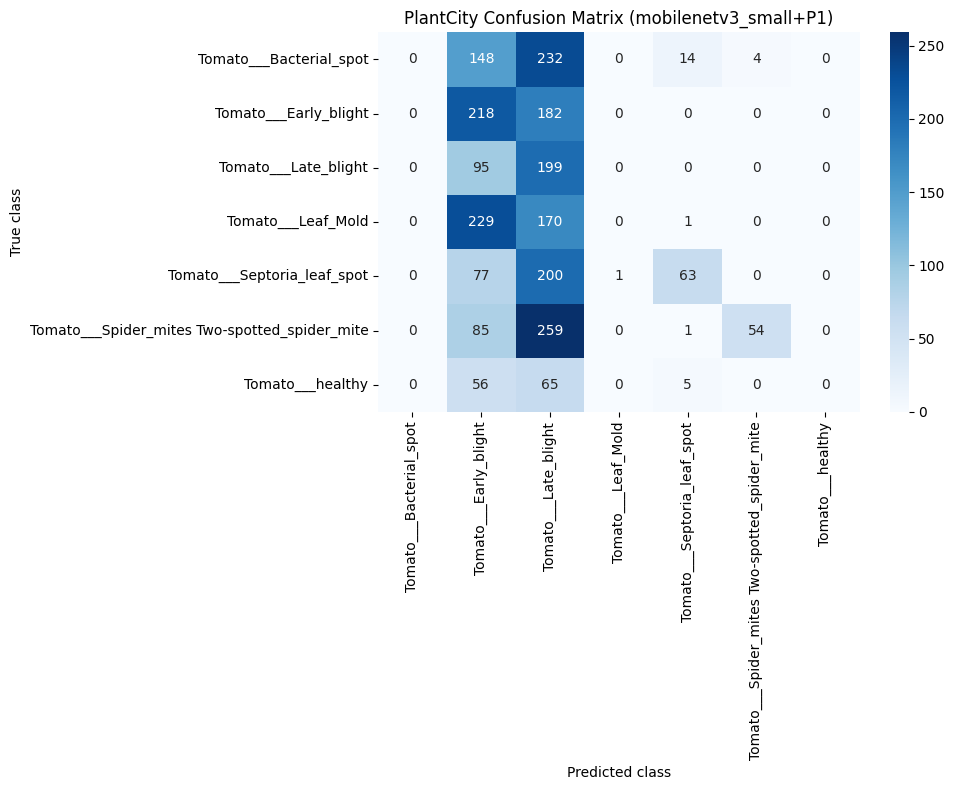


Saved to /content/drive/MyDrive/PlantDiseaseProject/results/figures/plantcity_confusion_matrix_diagnostic.png


In [ ]:
# Cell 36: Confusion matrix for PlantCity predictions — reveals the FAILURE PATTERN
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Use the stronger model for this diagnostic
best_checkpoint = os.path.join(EXPERIMENTS_DIR, "EXP_0032", 'checkpoint_best.keras')
model = tf.keras.models.load_model(best_checkpoint)

pc_ds = build_dataset(pc_eval_df, "P1", EXPERIMENT_MODES["FULL"]["batch_size"], shuffle=False, augment=False)

y_true, y_pred = [], []
for images, labels in pc_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

shared_class_names = [c for c in CLASS_NAMES if CLASS_TO_IDX[c] in shared_class_indices]
cm = confusion_matrix(y_true, y_pred, labels=shared_class_indices)

print("What the model predicted vs. what the true label was (rows=true, cols=predicted):")
cm_df = pd.DataFrame(cm, index=shared_class_names, columns=shared_class_names)
print(cm_df)

# Also: what fraction of ALL PlantCity predictions landed on each class, regardless of true label?
pred_distribution = pd.Series(y_pred).value_counts(normalize=True).sort_index()
print("\nOverall prediction distribution (is the model just guessing one class every time?):")
for idx, frac in pred_distribution.items():
    class_name = CLASS_NAMES[idx]
    marker = " <-- shared class" if idx in shared_class_indices else " <-- NOT a shared class!"
    print(f"  {class_name}: {frac:.1%}{marker}")

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("PlantCity Confusion Matrix (mobilenetv3_small+P1)")
plt.ylabel("True class")
plt.xlabel("Predicted class")
plt.tight_layout()
fig_path = os.path.join(DRIVE_ROOT, 'results', 'figures', 'plantcity_confusion_matrix_diagnostic.png')
plt.savefig(fig_path, dpi=100)
plt.show()
print(f"\nSaved to {fig_path}")

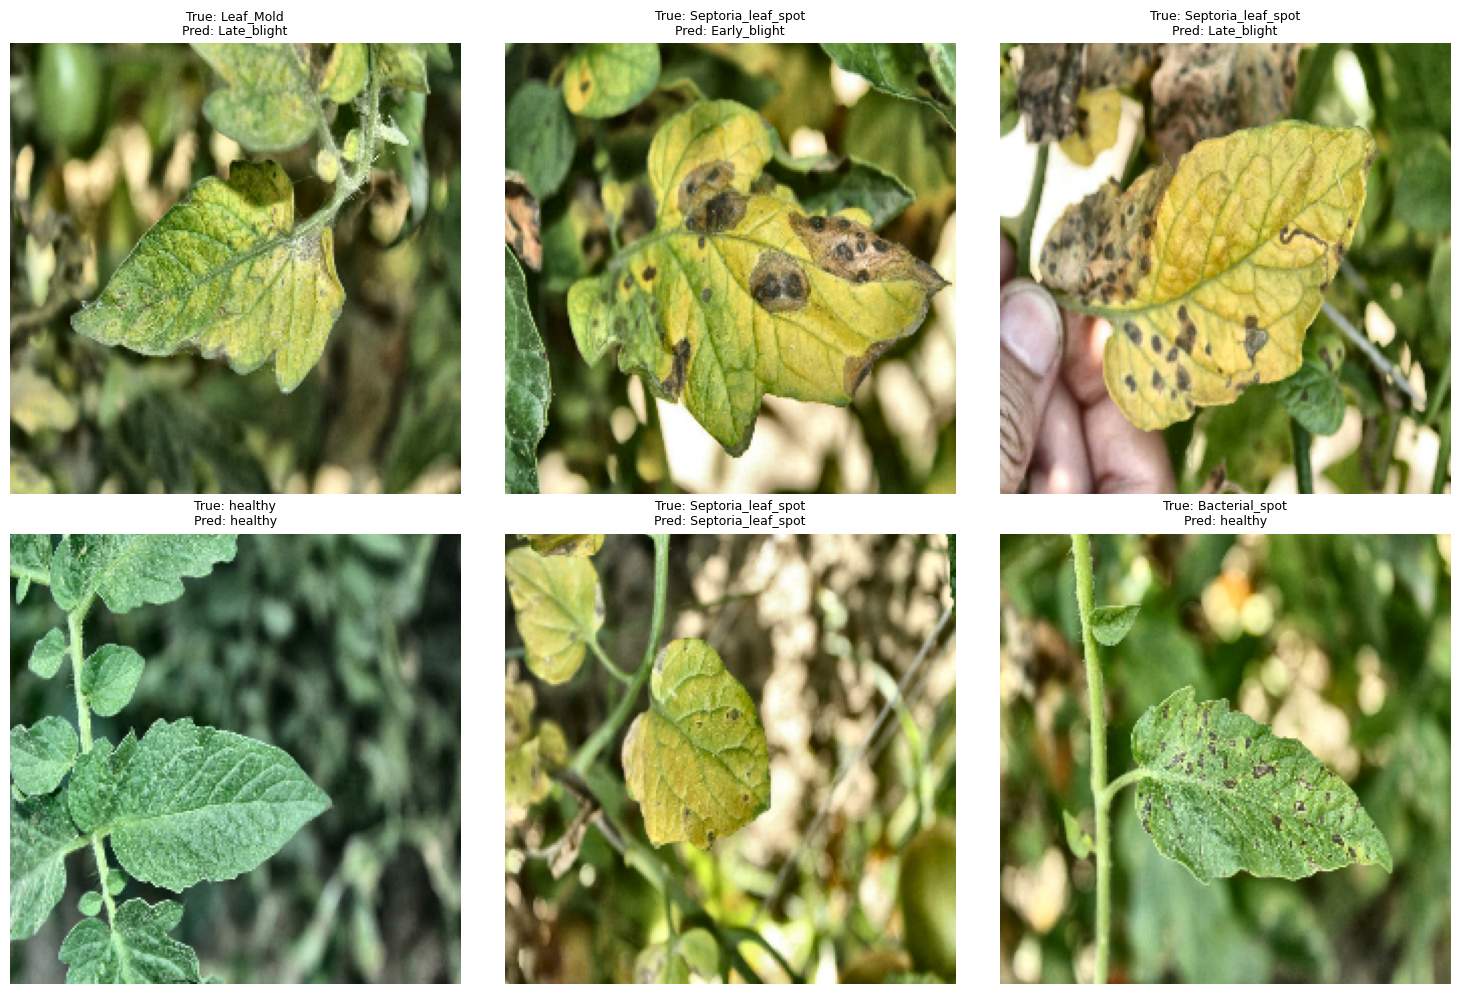

Saved to /content/drive/MyDrive/PlantDiseaseProject/results/figures/plantcity_pipeline_visual_check.png


In [ ]:
# Cell 37: Visually inspect actual PlantCity images as our pipeline loads them, with predictions
sample_pc = pc_eval_df.sample(6, random_state=RANDOM_SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, row in sample_pc.iterrows():
    img_p1 = load_image_p1(row["path"]).numpy()
    pred = model.predict(np.expand_dims(img_p1, 0), verbose=0)
    pred_class = CLASS_NAMES[np.argmax(pred)]

    ax = axes[i // 3, i % 3]
    ax.imshow(img_p1)
    ax.set_title(f"True: {row['class'].replace('Tomato___','')}\nPred: {pred_class.replace('Tomato___','')}",
                 fontsize=9)
    ax.axis("off")

plt.tight_layout()
fig_path = os.path.join(DRIVE_ROOT, 'results', 'figures', 'plantcity_pipeline_visual_check.png')
plt.savefig(fig_path, dpi=100)
plt.show()
print(f"Saved to {fig_path}")

In [ ]:
# Cell 38: Grad-CAM implementation
import matplotlib.cm as cm

def get_last_conv_layer_name(model):
    """Scan backward through the model's layers and return the name of the last
    one with a 4D (spatial) output — i.e. the last conv-like layer before pooling/flattening."""
    for layer in reversed(model.layers):
        try:
            shape = layer.output.shape
        except AttributeError:
            continue
        if len(shape) == 4:
            return layer.name
    raise ValueError("No 4D (spatial) layer found in this model.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Standard Grad-CAM: gradient of the top predicted class w.r.t. the last conv
    layer's feature maps, used to weight and sum those maps into a heatmap."""
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # importance weight per channel

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)  # ReLU + normalize
    return heatmap.numpy(), int(pred_index)

def overlay_gradcam(img_uint8, heatmap, alpha=0.4):
    """Resize the (small) heatmap up to image size and blend it over the original image."""
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (img_uint8.shape[0], img_uint8.shape[1]))
    heatmap_resized = tf.squeeze(heatmap_resized).numpy()
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[np.uint8(255 * heatmap_resized)]
    overlaid = jet_heatmap * alpha + (img_uint8 / 255.0) * (1 - alpha)
    return np.clip(overlaid, 0, 1)

print("Grad-CAM functions defined.")

Grad-CAM functions defined.


Using last conv layer: activation_53


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_7']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_1076/2079915250.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


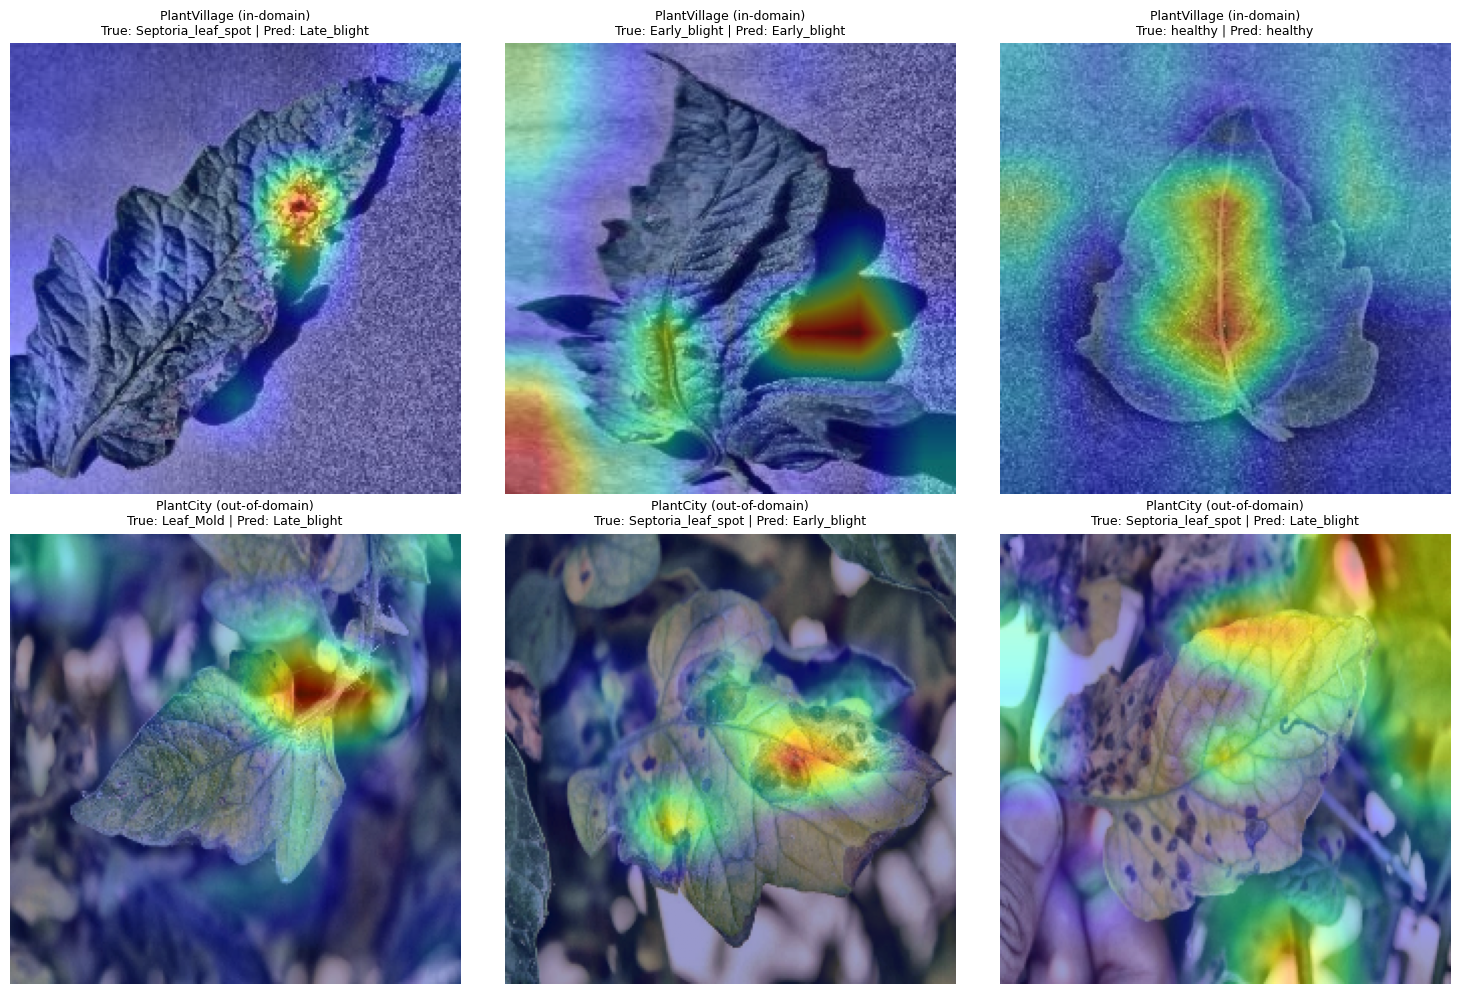

Saved to /content/drive/MyDrive/PlantDiseaseProject/results/figures/gradcam/gradcam_pv_vs_pc_comparison.png


In [ ]:
# Cell 39: Grad-CAM comparison — PlantVillage (in-domain) vs PlantCity (out-of-domain)
gradcam_model = tf.keras.models.load_model(os.path.join(EXPERIMENTS_DIR, "EXP_0032", 'checkpoint_best.keras'))
last_conv = get_last_conv_layer_name(gradcam_model)
print(f"Using last conv layer: {last_conv}")

gradcam_dir = os.path.join(DRIVE_ROOT, 'results', 'figures', 'gradcam')
os.makedirs(gradcam_dir, exist_ok=True)

# 3 PlantVillage test examples + 3 PlantCity examples
pv_samples = test_df.sample(3, random_state=RANDOM_SEED).reset_index(drop=True)
pc_samples = pc_eval_df.sample(3, random_state=RANDOM_SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, row in pv_samples.iterrows():
    img_float = load_image_p1(row["path"]).numpy()
    img_uint8 = (img_float * 255).astype(np.uint8)
    img_batch = np.expand_dims(img_float, 0)
    heatmap, pred_idx = make_gradcam_heatmap(img_batch, gradcam_model, last_conv)
    overlay = overlay_gradcam(img_uint8, heatmap)
    axes[0, i].imshow(overlay)
    true_name = row["class"].replace("Tomato___", "")
    pred_name = CLASS_NAMES[pred_idx].replace("Tomato___", "")
    axes[0, i].set_title(f"PlantVillage (in-domain)\nTrue: {true_name} | Pred: {pred_name}", fontsize=9)
    axes[0, i].axis("off")

for i, row in pc_samples.iterrows():
    img_float = load_image_p1(row["path"]).numpy()
    img_uint8 = (img_float * 255).astype(np.uint8)
    img_batch = np.expand_dims(img_float, 0)
    heatmap, pred_idx = make_gradcam_heatmap(img_batch, gradcam_model, last_conv)
    overlay = overlay_gradcam(img_uint8, heatmap)
    axes[1, i].imshow(overlay)
    true_name = row["class"].replace("Tomato___", "")
    pred_name = CLASS_NAMES[pred_idx].replace("Tomato___", "")
    axes[1, i].set_title(f"PlantCity (out-of-domain)\nTrue: {true_name} | Pred: {pred_name}", fontsize=9)
    axes[1, i].axis("off")

plt.tight_layout()
fig_path = os.path.join(gradcam_dir, 'gradcam_pv_vs_pc_comparison.png')
plt.savefig(fig_path, dpi=100)
plt.show()
print(f"Saved to {fig_path}")

In [ ]:
# Cell 40: Table I — Dataset Distribution (from dataset_report.json, nothing hand-typed)
with open(os.path.join(DRIVE_ROOT, 'reports', 'dataset_report.json')) as f:
    dataset_report = json.load(f)

tables_dir = os.path.join(DRIVE_ROOT, 'results', 'tables')
os.makedirs(tables_dir, exist_ok=True)

table1_rows = []
for cls in dataset_report["PlantVillage"]["class_names"]:
    count = dataset_report["PlantVillage"]["images_per_class"].get(cls, 0)
    pc_match = next((s["plantcity"] for s in class_mapping["shared_classes"] if s["plantvillage"] == cls), None)
    pc_count = dataset_report["PlantCity"]["images_per_class"].get(pc_match, 0) if pc_match else "N/A (not shared)"
    table1_rows.append({
        "Class": cls.replace("Tomato___", ""),
        "PlantVillage Count": count,
        "PlantCity Count": pc_count,
        "Shared": "Yes" if pc_match else "No"
    })

table1_df = pd.DataFrame(table1_rows)
table1_df.to_csv(os.path.join(tables_dir, 'table1_dataset_distribution.csv'), index=False)
print("=== Table I: Dataset Distribution ===")
print(table1_df.to_string(index=False))

=== Table I: Dataset Distribution ===
                               Class  PlantVillage Count  PlantCity Count Shared
                      Bacterial_spot                2127              400    Yes
                        Early_blight                1000              400    Yes
                         Late_blight                1909              294    Yes
                           Leaf_Mold                 952              400    Yes
                  Septoria_leaf_spot                1771              341    Yes
Spider_mites Two-spotted_spider_mite                1676              127    Yes
                         Target_Spot                1404 N/A (not shared)     No
       Tomato_Yellow_Leaf_Curl_Virus                5357 N/A (not shared)     No
                 Tomato_mosaic_virus                 373 N/A (not shared)     No
                             healthy                1591              400    Yes


In [ ]:
# Cell 41: Fill the metric gap — compute full metric set for both FULL candidates
from sklearn.metrics import precision_score, recall_score, accuracy_score

def compute_full_metrics(model, dataset, num_classes):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    labels_range = list(range(num_classes))
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average='macro', labels=labels_range, zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average='macro', labels=labels_range, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average='macro', labels=labels_range, zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average='weighted', labels=labels_range, zero_division=0),
    }

full_candidates = [
    {"exp_id": "EXP_0030", "model": "densenet121", "preprocessing": "P0"},
    {"exp_id": "EXP_0032", "model": "mobilenetv3_small", "preprocessing": "P1"},
]

full_metrics = {}
for c in full_candidates:
    checkpoint_path = os.path.join(EXPERIMENTS_DIR, c["exp_id"], 'checkpoint_best.keras')
    model = tf.keras.models.load_model(checkpoint_path)
    test_ds = build_dataset(test_df, c["preprocessing"], EXPERIMENT_MODES["FULL"]["batch_size"], shuffle=False, augment=False)
    metrics = compute_full_metrics(model, test_ds, NUM_CLASSES)
    full_metrics[c["exp_id"]] = {**c, **metrics}
    print(f"{c['model']}: {metrics}")
    del model

print("\nFull metrics computed for both FULL candidates.")

densenet121: {'accuracy': 0.8926470588235295, 'macro_precision': 0.8848924895502588, 'macro_recall': 0.8551555972572233, 'macro_f1': 0.8628663223103652, 'weighted_f1': 0.8898757569482401}
mobilenetv3_small: {'accuracy': 0.9055147058823529, 'macro_precision': 0.8910604065471309, 'macro_recall': 0.8803151069652799, 'macro_f1': 0.8797304215999487, 'weighted_f1': 0.9037776538447431}

Full metrics computed for both FULL candidates.


In [ ]:
# Cell 42: Tables II-V — auto-generated from experiment_log.csv, NOT_RUN where data doesn't exist
df = pd.read_csv(EXPERIMENT_LOG_PATH)
NOT_RUN_STR = "NOT RUN"

# --- Table II: Model Comparison ---
model_names = ["custom_cnn", "resnet18", "mobilenetv3_small", "densenet121"]
table2_rows = []
for m in model_names:
    model_rows = df[(df["model"] == m) & (df["experiment_status"] == "COMPLETED")]
    if len(model_rows) == 0:
        table2_rows.append({"Model": m, "Accuracy": NOT_RUN_STR, "Macro Precision": NOT_RUN_STR,
                             "Macro Recall": NOT_RUN_STR, "Macro F1": NOT_RUN_STR, "Weighted F1": NOT_RUN_STR,
                             "Params": NOT_RUN_STR, "Size (MB)": NOT_RUN_STR, "Latency (ms)": NOT_RUN_STR})
        continue
    best_exp_id = model_rows.loc[model_rows["validation_macro_f1"].astype(float).idxmax(), "experiment_id"]
    best_row = model_rows[model_rows["experiment_id"] == best_exp_id].iloc[0]

    if best_exp_id in full_metrics:  # one of our 2 fully-evaluated candidates
        fm = full_metrics[best_exp_id]
        table2_rows.append({
            "Model": m, "Accuracy": round(fm["accuracy"], 4), "Macro Precision": round(fm["macro_precision"], 4),
            "Macro Recall": round(fm["macro_recall"], 4), "Macro F1": round(fm["macro_f1"], 4),
            "Weighted F1": round(fm["weighted_f1"], 4),
            "Params": best_row["parameter_count"], "Size (MB)": best_row["model_size_mb"],
            "Latency (ms)": best_row["inference_latency_ms"],
        })
    else:  # PILOT-only model — only macro-F1 (val) exists, rest genuinely not computed
        table2_rows.append({
            "Model": m, "Accuracy": NOT_RUN_STR, "Macro Precision": NOT_RUN_STR, "Macro Recall": NOT_RUN_STR,
            "Macro F1": round(float(best_row["validation_macro_f1"]), 4) if best_row["validation_macro_f1"] != NOT_RUN_STR else NOT_RUN_STR,
            "Weighted F1": NOT_RUN_STR,
            "Params": best_row["parameter_count"], "Size (MB)": best_row["model_size_mb"],
            "Latency (ms)": best_row["inference_latency_ms"],
        })

table2_df = pd.DataFrame(table2_rows)
table2_df.to_csv(os.path.join(tables_dir, 'table2_model_comparison.csv'), index=False)
print("=== Table II: Model Comparison ===")
print(table2_df.to_string(index=False))
print("\nNote: custom_cnn/resnet18 only ran at PILOT scale (accuracy/precision/recall/weighted-F1 not computed) — a resource-driven scope decision.")

# --- Table III: Preprocessing Ablation (PILOT scale, as decided) ---
table3_rows = []
for m in model_names:
    row = {"Model": m}
    for p in ["P0", "P1", "P2"]:
        matches = df[(df["model"] == m) & (df["preprocessing"] == p) & (df["experiment_status"] == "COMPLETED")]
        if len(matches) == 0:
            row[p] = NOT_RUN_STR
        else:
            row[p] = round(float(matches.iloc[-1]["validation_macro_f1"]), 4)
    table3_rows.append(row)
table3_df = pd.DataFrame(table3_rows)
table3_df.to_csv(os.path.join(tables_dir, 'table3_preprocessing_ablation.csv'), index=False)
print("\n=== Table III: Preprocessing Ablation (val macro-F1, PILOT scale) ===")
print(table3_df.to_string(index=False))

# --- Table IV: Cross-Domain Generalization ---
table4_rows = []
for c in full_candidates:
    row = df[df["experiment_id"] == c["exp_id"]].iloc[0]
    table4_rows.append({
        "Model": c["model"],
        "PlantVillage Test Macro-F1": round(float(row["test_macro_f1"]), 4) if row["test_macro_f1"] != NOT_RUN_STR else NOT_RUN_STR,
        "PlantCity Macro-F1": round(float(row["PlantCity_macro_f1"]), 4) if row["PlantCity_macro_f1"] != NOT_RUN_STR else NOT_RUN_STR,
        "Generalization Gap": round(float(row["generalization_gap"]), 4) if row["generalization_gap"] != NOT_RUN_STR else NOT_RUN_STR,
    })
for m in ["custom_cnn", "resnet18"]:
    table4_rows.append({"Model": m, "PlantVillage Test Macro-F1": NOT_RUN_STR,
                         "PlantCity Macro-F1": NOT_RUN_STR, "Generalization Gap": NOT_RUN_STR})
table4_df = pd.DataFrame(table4_rows)
table4_df.to_csv(os.path.join(tables_dir, 'table4_cross_domain_generalization.csv'), index=False)
print("\n=== Table IV: Cross-Domain Generalization ===")
print(table4_df.to_string(index=False))

# --- Table V: Efficiency Comparison ---
table5_df = table2_df[["Model", "Macro F1", "Params", "Size (MB)", "Latency (ms)"]].copy()
table5_df.to_csv(os.path.join(tables_dir, 'table5_efficiency_comparison.csv'), index=False)
print("\n=== Table V: Efficiency Comparison ===")
print(table5_df.to_string(index=False))

print(f"\nAll 5 tables saved to {tables_dir}")

=== Table II: Model Comparison ===
            Model Accuracy Macro Precision Macro Recall  Macro F1 Weighted F1   Params Size (MB) Latency (ms)
       custom_cnn  NOT RUN         NOT RUN      NOT RUN    0.6048     NOT RUN  1242538    14.313       137.61
         resnet18  NOT RUN         NOT RUN      NOT RUN    0.5307     NOT RUN 11191242    128.28      105.915
mobilenetv3_small   0.9055          0.8911       0.8803    0.8797      0.9038   944890     4.186       93.002
      densenet121   0.8926          0.8849       0.8552    0.8629      0.8899  7047754    28.405      185.323

Note: custom_cnn/resnet18 only ran at PILOT scale (accuracy/precision/recall/weighted-F1 not computed) — a resource-driven scope decision.

=== Table III: Preprocessing Ablation (val macro-F1, PILOT scale) ===
            Model     P0     P1     P2
       custom_cnn 0.0182 0.5979 0.5154
         resnet18 0.5307 0.4518 0.4593
mobilenetv3_small 0.7663 0.8836 0.7999
      densenet121 0.8469 0.7358 0.7356

=== Tabl

In [ ]:
# Cell 42b (corrected): Table III — filtered by PILOT mode, read from each experiment's config.json
def get_experiment_mode(exp_id):
    """Mode isn't a column in experiment_log.csv (a real gap in the logger schema),
    but it IS saved in each experiment's own config.json — read it from there."""
    config_path = os.path.join(EXPERIMENTS_DIR, exp_id, 'config.json')
    try:
        with open(config_path) as f:
            return json.load(f).get("mode", None)
    except FileNotFoundError:
        return None

df = pd.read_csv(EXPERIMENT_LOG_PATH)  # re-read in case it changed
df["mode"] = df["experiment_id"].apply(get_experiment_mode)  # backfill mode via config lookup

table3_rows = []
for m in model_names:
    row = {"Model": m}
    for p in ["P0", "P1", "P2"]:
        matches = df[(df["model"] == m) & (df["preprocessing"] == p) &
                     (df["mode"] == "PILOT") & (df["experiment_status"] == "COMPLETED")]
        if len(matches) == 0:
            row[p] = "NOT RUN"
        else:
            row[p] = round(float(matches.iloc[-1]["validation_macro_f1"]), 4)
    table3_rows.append(row)
table3_df = pd.DataFrame(table3_rows)
table3_df.to_csv(os.path.join(tables_dir, 'table3_preprocessing_ablation.csv'), index=False)
print("=== Table III: Preprocessing Ablation (val macro-F1, PILOT scale ONLY) ===")
print(table3_df.to_string(index=False))

=== Table III: Preprocessing Ablation (val macro-F1, PILOT scale ONLY) ===
            Model     P0     P1     P2
       custom_cnn 0.5097 0.5979 0.5154
         resnet18 0.5307 0.4518 0.4593
mobilenetv3_small 0.7663 0.7880 0.7999
      densenet121 0.7635 0.7358 0.7356


In [ ]:
# Cell 42c: Quick supplementary PILOT run to complete Table III properly
exp_id, _ = run_experiment(
    model_name="custom_cnn", preprocessing_name="P0", mode="PILOT",
    notes="Supplementary PILOT run to complete Table III — no genuine PILOT-scale custom_cnn+P0 "
          "result existed on this account (only a DEBUG-mode smoke test, EXP_0001)."
)

Started EXP_0033 — config saved to /content/drive/MyDrive/PlantDiseaseProject/results/experiments/EXP_0033/config.json


/tmp/ipykernel_780/1077540883.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("class", group_keys=False).apply(
/tmp/ipykernel_780/1077540883.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("class", group_keys=False).apply(


Epoch 1/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 79s 379ms/step - accuracy: 0.5214 - loss: 1.4502 - val_accuracy: 0.0844 - val_loss: 4.8055
Epoch 2/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 46s 243ms/step - accuracy: 0.6316 - loss: 1.1305 - val_accuracy: 0.1963 - val_loss: 5.4618
Epoch 3/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 250ms/step - accuracy: 0.6490 - loss: 1.0614 - val_accuracy: 0.3028 - val_loss: 2.9787
Epoch 4/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 250ms/step - accuracy: 0.6974 - loss: 0.9131 - val_accuracy: 0.5321 - val_loss: 2.5913
Epoch 5/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 39s 244ms/step - accuracy: 0.7064 - loss: 0.8803 - val_accuracy: 0.5046 - val_loss: 3.4244
Epoch 6/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 39s 243ms/step - accuracy: 0.7340 - loss: 0.7851 - val_accuracy: 0.5431 - val_loss: 1.9366
Epoch 7/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 251ms/step - accuracy: 0.7473 - loss: 0.7442 - val_accuracy: 0.2844 - val_loss: 3.8122
Epoch 8/8
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 252ms/step - accuracy: 0.7607 - loss: 0.7033 - 

In [ ]:
# Re-run the same Table III generation cell to pick up EXP_0033
df = pd.read_csv(EXPERIMENT_LOG_PATH)
df["mode"] = df["experiment_id"].apply(get_experiment_mode)

table3_rows = []
for m in model_names:
    row = {"Model": m}
    for p in ["P0", "P1", "P2"]:
        matches = df[(df["model"] == m) & (df["preprocessing"] == p) &
                     (df["mode"] == "PILOT") & (df["experiment_status"] == "COMPLETED")]
        if len(matches) == 0:
            row[p] = "NOT RUN"
        else:
            row[p] = round(float(matches.iloc[-1]["validation_macro_f1"]), 4)
    table3_rows.append(row)
table3_df = pd.DataFrame(table3_rows)
table3_df.to_csv(os.path.join(tables_dir, 'table3_preprocessing_ablation.csv'), index=False)
print(table3_df.to_string(index=False))

            Model     P0     P1     P2
       custom_cnn 0.5926 0.5979 0.5154
         resnet18 0.5307 0.4518 0.4593
mobilenetv3_small 0.7663 0.7880 0.7999
      densenet121 0.7635 0.7358 0.7356


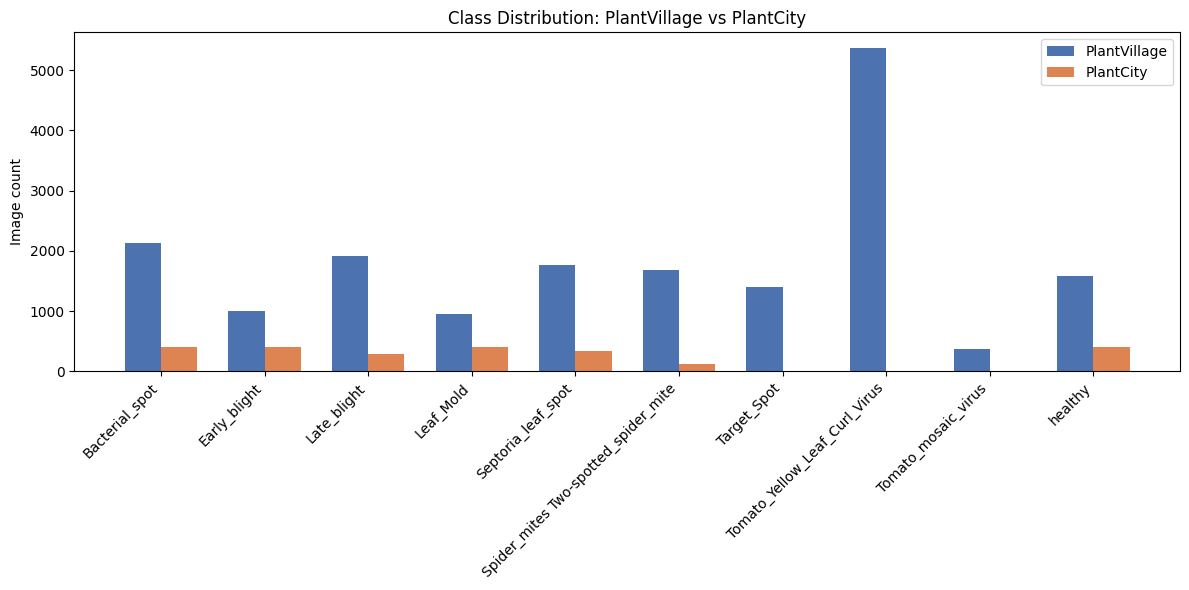

Saved fig1_class_distribution.png


In [ ]:
# Cell 43: Figure 1 — class distribution, PlantVillage vs PlantCity
figures_dir = os.path.join(DRIVE_ROOT, 'results', 'figures')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(table1_df))
width = 0.35

pv_counts = table1_df["PlantVillage Count"].values
pc_counts = [v if isinstance(v, (int, np.integer)) else 0 for v in table1_df["PlantCity Count"].values]

ax.bar(x - width/2, pv_counts, width, label='PlantVillage', color='#4C72B0')
ax.bar(x + width/2, pc_counts, width, label='PlantCity', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(table1_df["Class"], rotation=45, ha='right')
ax.set_ylabel("Image count")
ax.set_title("Class Distribution: PlantVillage vs PlantCity")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig1_class_distribution.png'), dpi=100)
plt.show()
print("Saved fig1_class_distribution.png")

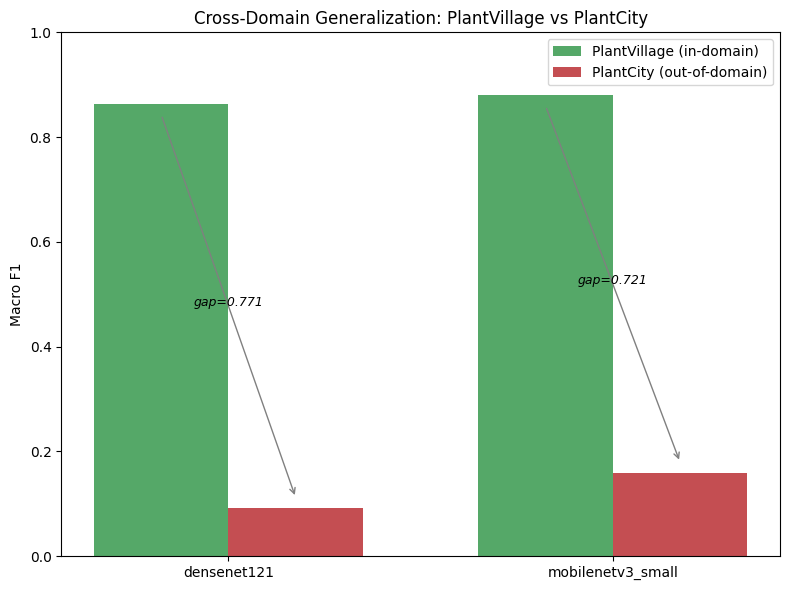

Saved fig2_generalization_gap.png


In [ ]:
# Cell 44: Figure 2 — PlantVillage test vs PlantCity performance (the core finding)
fig, ax = plt.subplots(figsize=(8, 6))
models_plot = ["densenet121", "mobilenetv3_small"]
pv_scores = [0.8629, 0.8797]
pc_scores = [0.0915, 0.1592]

x = np.arange(len(models_plot))
width = 0.35
ax.bar(x - width/2, pv_scores, width, label='PlantVillage (in-domain)', color='#55A868')
ax.bar(x + width/2, pc_scores, width, label='PlantCity (out-of-domain)', color='#C44E52')

for i, (pv, pc) in enumerate(zip(pv_scores, pc_scores)):
    ax.annotate('', xy=(i + width/2, pc + 0.02), xytext=(i - width/2, pv - 0.02),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))
    ax.text(i, (pv + pc) / 2, f'gap={pv-pc:.3f}', ha='center', fontsize=9, style='italic')

ax.set_xticks(x)
ax.set_xticklabels(models_plot)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.set_title("Cross-Domain Generalization: PlantVillage vs PlantCity")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig2_generalization_gap.png'), dpi=100)
plt.show()
print("Saved fig2_generalization_gap.png")

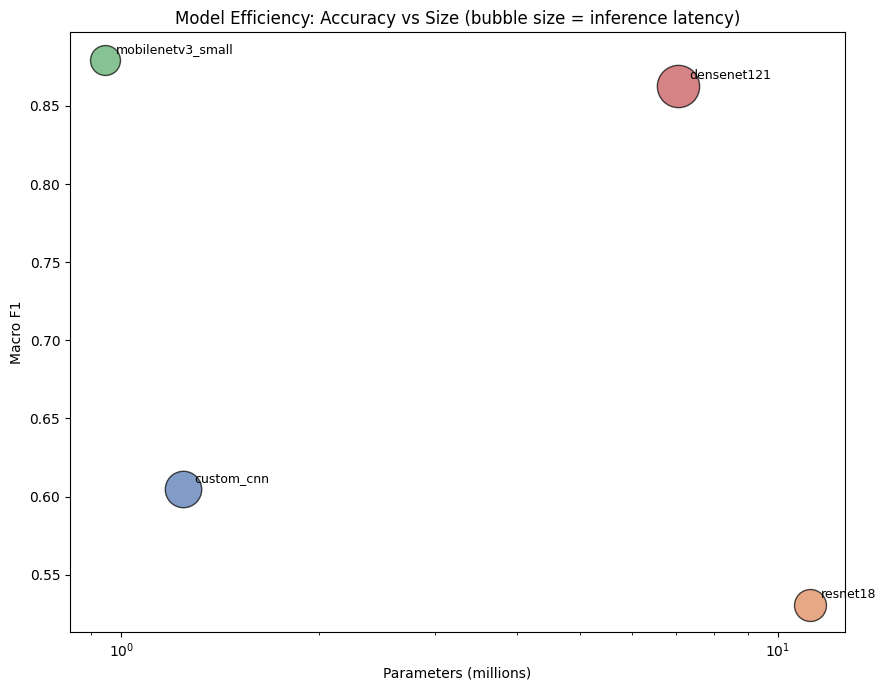

Saved fig3_efficiency_comparison.png


In [ ]:
# Cell 45: Figure 3 — accuracy vs efficiency tradeoff (params size = latency)
fig, ax = plt.subplots(figsize=(9, 7))
eff_df = table2_df[table2_df["Macro F1"] != "NOT RUN"].copy()
eff_df["Macro F1"] = eff_df["Macro F1"].astype(float)
eff_df["Params"] = eff_df["Params"].astype(float)
eff_df["Latency (ms)"] = eff_df["Latency (ms)"].astype(float)

colors = {'custom_cnn': '#4C72B0', 'resnet18': '#DD8452', 'mobilenetv3_small': '#55A868', 'densenet121': '#C44E52'}
for _, row in eff_df.iterrows():
    ax.scatter(row["Params"] / 1e6, row["Macro F1"], s=row["Latency (ms)"] * 5,
               color=colors.get(row["Model"], 'gray'), alpha=0.7, edgecolors='black', linewidth=1)
    ax.annotate(row["Model"], (row["Params"] / 1e6, row["Macro F1"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

ax.set_xlabel("Parameters (millions)")
ax.set_ylabel("Macro F1")
ax.set_title("Model Efficiency: Accuracy vs Size (bubble size = inference latency)")
ax.set_xscale('log')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig3_efficiency_comparison.png'), dpi=100)
plt.show()
print("Saved fig3_efficiency_comparison.png")

In [ ]:
# Cell 46: Paper-readiness check — programmatic checklist, no hand-typed claims
df = pd.read_csv(EXPERIMENT_LOG_PATH)

n_completed = (df["experiment_status"] == "COMPLETED").sum()
n_failed = (df["experiment_status"] == "FAILED").sum()
n_skipped = (df["experiment_status"] == "SKIPPED").sum()
n_running = (df["experiment_status"] == "RUNNING").sum()

final_candidates = ["densenet121 (P0)", "mobilenetv3_small (P1)"]

pv_test_done = df[df["experiment_id"].isin(["EXP_0030", "EXP_0032"])]["test_macro_f1"].apply(
    lambda x: x != "NOT RUN" and pd.notna(x)).all()
pc_eval_done = df[df["experiment_id"].isin(["EXP_0030", "EXP_0032"])]["PlantCity_macro_f1"].apply(
    lambda x: x != "NOT RUN" and pd.notna(x)).all()
gradcam_done = os.path.exists(os.path.join(figures_dir, 'gradcam', 'gradcam_pv_vs_pc_comparison.png'))
efficiency_done = os.path.exists(os.path.join(tables_dir, 'table5_efficiency_comparison.csv'))

tables_exist = all(os.path.exists(os.path.join(tables_dir, f))
                    for f in ['table1_dataset_distribution.csv', 'table2_model_comparison.csv',
                              'table3_preprocessing_ablation.csv', 'table4_cross_domain_generalization.csv',
                              'table5_efficiency_comparison.csv'])

not_run_remaining = []
for exp_id in ["EXP_0030", "EXP_0032"]:
    row = df[df["experiment_id"] == exp_id].iloc[0]
    for field in ["test_macro_f1", "PlantCity_macro_f1", "generalization_gap"]:
        if row[field] == "NOT RUN" or pd.isna(row[field]):
            not_run_remaining.append(f"{exp_id}: {field}")

print("="*60)
print("PAPER-READINESS CHECK")
print("="*60)
print(f"Datasets audited:                  Yes (PlantVillage + PlantCity, reports/dataset_report.*)")
print(f"Total experiments logged:          {len(df)}")
print(f"  Completed:                       {n_completed}")
print(f"  Failed:                          {n_failed}")
print(f"  Skipped:                         {n_skipped}")
print(f"  Still RUNNING (should be 0):     {n_running}")
print(f"Final selected model(s):           {', '.join(final_candidates)}")
print(f"PlantVillage test evaluation done: {'Yes' if pv_test_done else 'NO — incomplete'}")
print(f"PlantCity external evaluation done:{'Yes' if pc_eval_done else 'NO — incomplete'}")
print(f"Grad-CAM generated:                {'Yes' if gradcam_done else 'NO — missing'}")
print(f"Efficiency benchmarking done:      {'Yes' if efficiency_done else 'NO — missing'}")
print(f"All 5 tables generated:            {'Yes' if tables_exist else 'NO — missing some'}")
print(f"Any required result still NOT RUN: {'None' if not not_run_remaining else not_run_remaining}")
print("="*60)

if n_running > 0:
    print("\nWARNING: some experiments still show RUNNING status — check for stuck records before finalizing.")
if not_run_remaining:
    print("\nWARNING: incomplete results found — resolve before writing the Conclusion section.")
if n_running == 0 and not not_run_remaining and tables_exist and gradcam_done:
    print("\n✅ All core requirements met — ready to write Results/Discussion/Conclusion.")

PAPER-READINESS CHECK
Datasets audited:                  Yes (PlantVillage + PlantCity, reports/dataset_report.*)
Total experiments logged:          33
  Completed:                       26
  Failed:                          5
  Skipped:                         0
  Still RUNNING (should be 0):     2
Final selected model(s):           densenet121 (P0), mobilenetv3_small (P1)
PlantVillage test evaluation done: Yes
PlantCity external evaluation done:Yes
Grad-CAM generated:                Yes
Efficiency benchmarking done:      Yes
All 5 tables generated:            Yes
Any required result still NOT RUN: None



In [ ]:
# Cell 47: Identify and close out any lingering RUNNING experiments
df = pd.read_csv(EXPERIMENT_LOG_PATH)
running = df[df["experiment_status"] == "RUNNING"]
print("Stuck RUNNING experiments:")
print(running[["experiment_id", "model", "preprocessing", "completed_epochs", "timestamp", "notes"]])

Stuck RUNNING experiments:
   experiment_id       model preprocessing  completed_epochs  \
11      EXP_0012  custom_cnn            P0                 0   
12      EXP_0013  custom_cnn            P0                 0   

                           timestamp    notes  
11  2026-08-26T05:51:21.553599+00:00  NOT RUN  
12  2026-08-26T06:07:09.002912+00:00  NOT RUN  


In [ ]:
for exp_id in ["EXP_0012", "EXP_0013"]:
    logger.fail(exp_id, reason="Session ended/disconnected before this experiment produced any completed "
                                 "epochs; a later successful run of the same model/preprocessing combination "
                                 "(custom_cnn+P0, PILOT) exists elsewhere in the log.")
print("Both records closed out.")

EXP_0012 marked FAILED: Session ended/disconnected before this experiment produced any completed epochs; a later successful run of the same model/preprocessing combination (custom_cnn+P0, PILOT) exists elsewhere in the log.
EXP_0013 marked FAILED: Session ended/disconnected before this experiment produced any completed epochs; a later successful run of the same model/preprocessing combination (custom_cnn+P0, PILOT) exists elsewhere in the log.
Both records closed out.


In [ ]:
df = pd.read_csv(EXPERIMENT_LOG_PATH)
print("Remaining RUNNING count:", (df["experiment_status"] == "RUNNING").sum())

Remaining RUNNING count: 0


In [ ]:
figures_dir = os.path.join(DRIVE_ROOT, 'results', 'figures')
os.makedirs(figures_dir, exist_ok=True)
print("figures_dir restored.")

figures_dir restored.


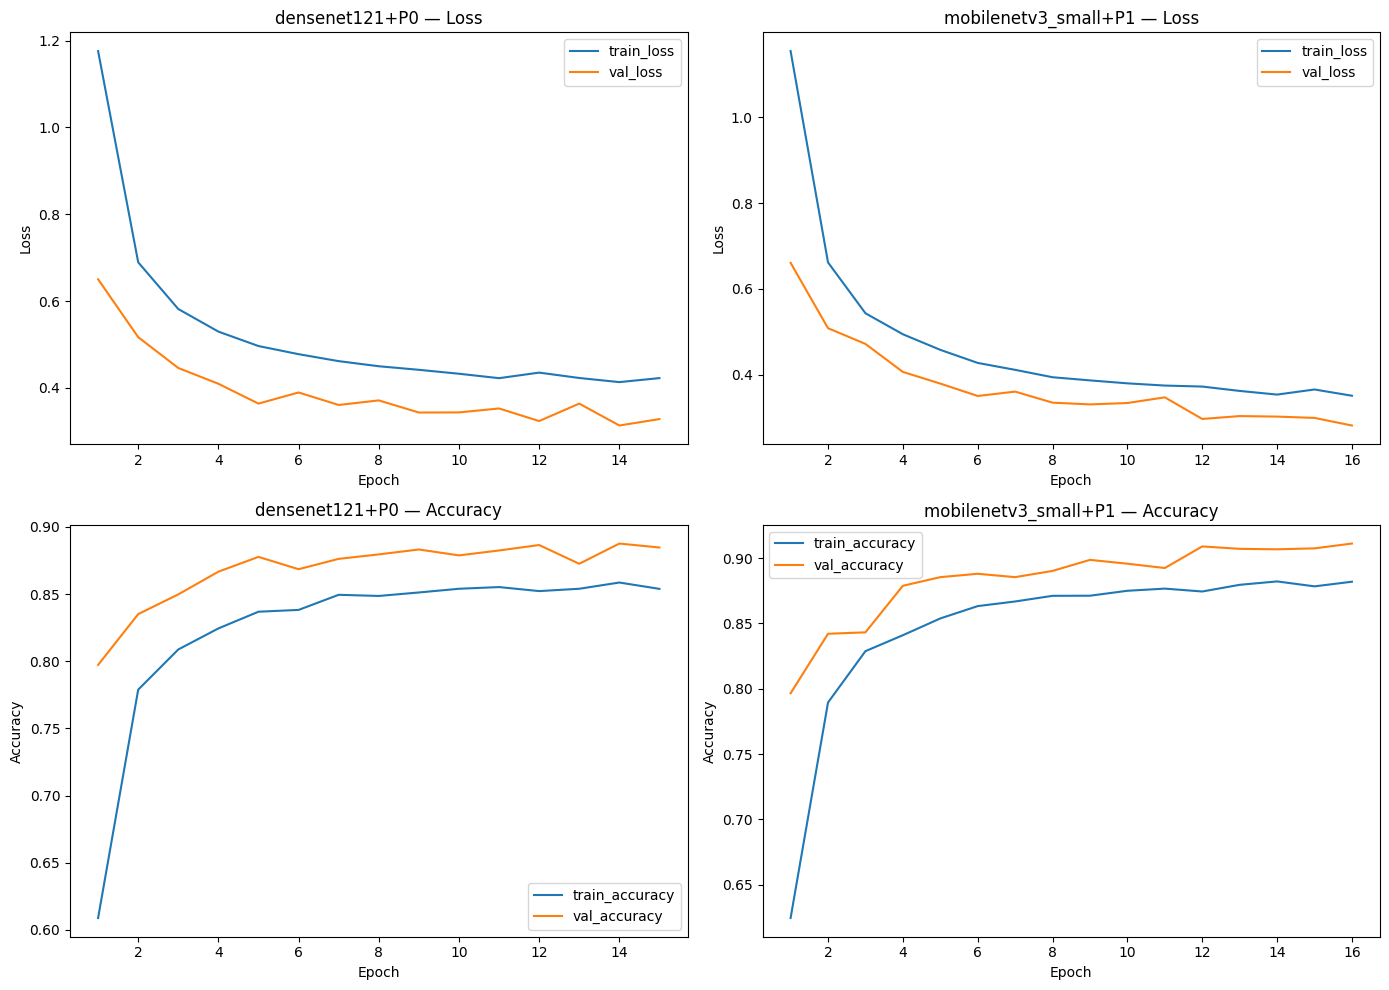

Saved fig4_training_curves.png


In [ ]:
# Cell 48: Loss and accuracy curves from each experiment's training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, exp_id in enumerate(["EXP_0030", "EXP_0032"]):
    hist = pd.read_csv(os.path.join(EXPERIMENTS_DIR, exp_id, 'training_history.csv'))
    model_name = "densenet121+P0" if exp_id == "EXP_0030" else "mobilenetv3_small+P1"

    axes[0, i].plot(hist["epoch"], hist["loss"], label="train_loss")
    axes[0, i].plot(hist["epoch"], hist["val_loss"], label="val_loss")
    axes[0, i].set_title(f"{model_name} — Loss")
    axes[0, i].set_xlabel("Epoch"); axes[0, i].set_ylabel("Loss")
    axes[0, i].legend()

    axes[1, i].plot(hist["epoch"], hist["accuracy"], label="train_accuracy")
    axes[1, i].plot(hist["epoch"], hist["val_accuracy"], label="val_accuracy")
    axes[1, i].set_title(f"{model_name} — Accuracy")
    axes[1, i].set_xlabel("Epoch"); axes[1, i].set_ylabel("Accuracy")
    axes[1, i].legend()

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig4_training_curves.png'), dpi=100)
plt.show()
print("Saved fig4_training_curves.png")

In [ ]:
full_candidates = [
    {"exp_id": "EXP_0030", "model": "densenet121", "preprocessing": "P0"},
    {"exp_id": "EXP_0032", "model": "mobilenetv3_small", "preprocessing": "P1"},
]
print("full_candidates restored.")

full_candidates restored.


In [ ]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
print("Imports confirmed.")

Imports confirmed.


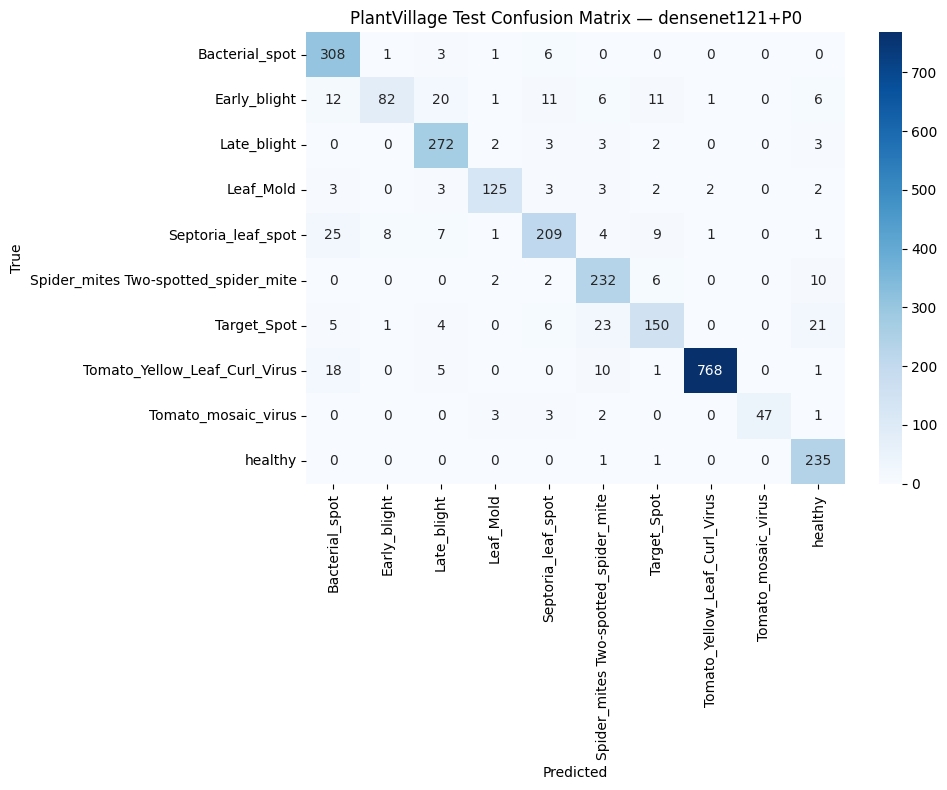

Saved cm_densenet121_P0_plantvillage_test.png


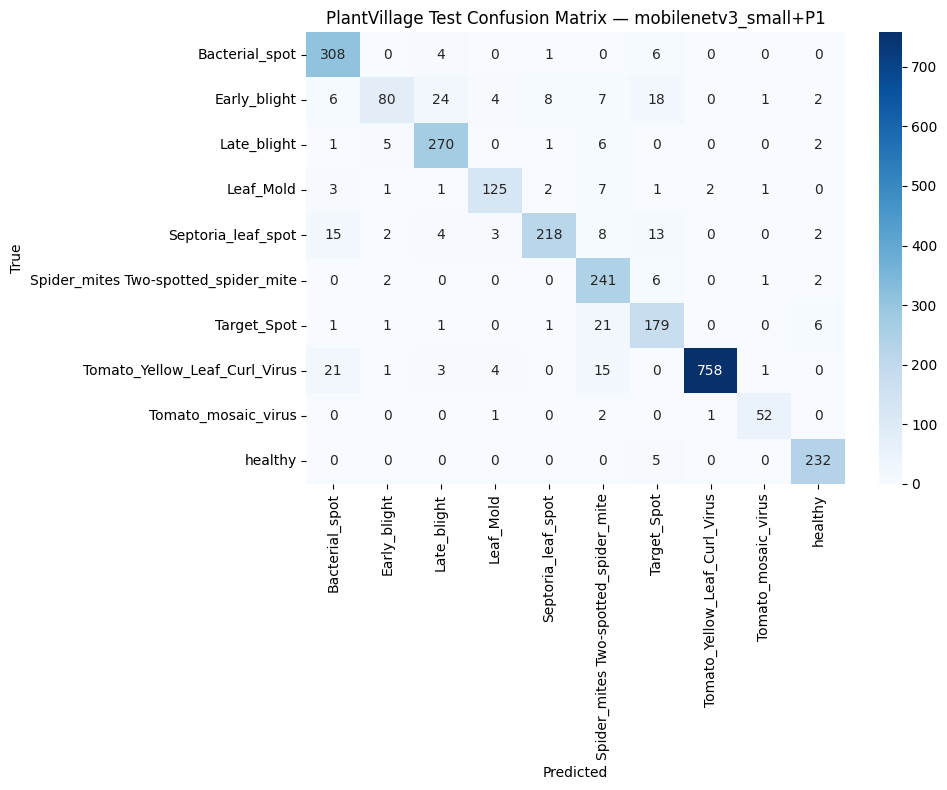

Saved cm_mobilenetv3_small_P1_plantvillage_test.png


In [ ]:
# Cell 49: Confusion matrices on PlantVillage TEST set, saved with deterministic filenames
cm_dir = os.path.join(figures_dir, 'confusion_matrices')
os.makedirs(cm_dir, exist_ok=True)

for c in full_candidates:
    checkpoint_path = os.path.join(EXPERIMENTS_DIR, c["exp_id"], 'checkpoint_best.keras')
    model = tf.keras.models.load_model(checkpoint_path)
    test_ds = build_dataset(test_df, c["preprocessing"], EXPERIMENT_MODES["FULL"]["batch_size"],
                             shuffle=False, augment=False)

    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    short_names = [n.replace("Tomato___", "") for n in CLASS_NAMES]

    plt.figure(figsize=(10, 8))
    sns.heatmap(pd.DataFrame(cm, index=short_names, columns=short_names), annot=True, fmt='d', cmap='Blues')
    plt.title(f"PlantVillage Test Confusion Matrix — {c['model']}+{c['preprocessing']}")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    fname = f"cm_{c['model']}_{c['preprocessing']}_plantvillage_test.png"
    plt.savefig(os.path.join(cm_dir, fname), dpi=100)
    plt.show()
    print(f"Saved {fname}")
    del model

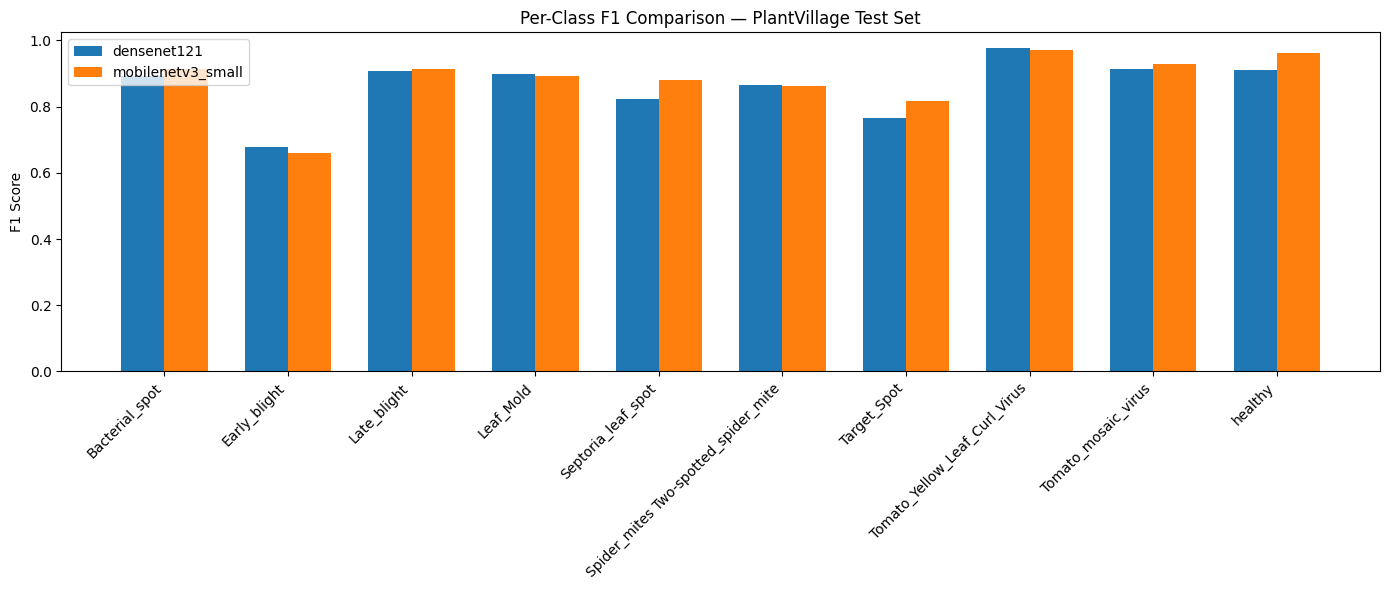

Saved fig5_per_class_f1.png


In [ ]:
# Cell 50: Per-class F1 comparison, both FULL candidates, PlantVillage test set
from sklearn.metrics import f1_score

per_class_f1 = {}
for c in full_candidates:
    checkpoint_path = os.path.join(EXPERIMENTS_DIR, c["exp_id"], 'checkpoint_best.keras')
    model = tf.keras.models.load_model(checkpoint_path)
    test_ds = build_dataset(test_df, c["preprocessing"], EXPERIMENT_MODES["FULL"]["batch_size"],
                             shuffle=False, augment=False)
    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    per_class_f1[c["model"]] = f1_score(y_true, y_pred, average=None, labels=list(range(NUM_CLASSES)))
    del model

short_names = [n.replace("Tomato___", "") for n in CLASS_NAMES]
x = np.arange(len(short_names))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
for i, (model_name, f1s) in enumerate(per_class_f1.items()):
    ax.bar(x + (i - 0.5) * width, f1s, width, label=model_name)
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Comparison — PlantVillage Test Set")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'fig5_per_class_f1.png'), dpi=100)
plt.show()
print("Saved fig5_per_class_f1.png")